# Shopper Intelligence Model
## ESCP × Catalina Hackathon — March 2026

---

### Challenge
> *"How can transactional data and external data be used to steer and optimise an omnichannel activation strategy (channel selection, touchpoints, timing) and to measure its overall marketing performance?"*

---

### Our Approach — Gamified Shopper Activation System

**Core concept:**  
A gamified shopper activation system that encourages healthier and more sustainable grocery purchases by combining transactional signals with product-level nutritional and environmental intelligence.

**Why this approach?**  
Traditional retail marketing segments shoppers by spend and frequency alone.  
We argue that *what* a shopper buys matters as much as *how much* they spend.  
By layering Open Food Facts product intelligence over transactional data, we can:

1. **Profile basket quality** — NutriScore, EcoScore (1–7 scale), NOVA group per transaction  
2. **Segment meaningfully** — combine behavioural AND health/sustainability signals  
3. **Activate precisely** — trigger right mission, right channel, right timing per shopper  
4. **Gamify engagement** — Bronze/Silver/Gold tiers, streaks, and mission completion  
5. **Measure rigorously** — exposed vs control, pre/post KPI comparison framework

---

### Data Architecture

| Layer | Source | Coverage |
|-------|--------|----------|
| Transactions | `ESCP_OVERALL_RECEIPT_2026_V2.parquet` | All shoppers |
| Product lines | `ESCP_DETAILED_RECEIPT_2026_V2.parquet` | All transactions |
| Product scores | `Categorized_Products_Result.csv` | Validated categories + scores |
| Shoppers | `ESCP_CONSUMER_2026_V2.parquet` | All cardholders |
| Offers/Events | `ESCP_EVENTS_2026_V2.parquet` | All events |


In [22]:
# DEPENDENCIES
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'pyarrow'],
    check=False
)
print('Dependencies ready')

Dependencies ready


In [23]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

print('Imports ready')

Imports ready


---
## Section 1 — Load & Inspect Data

In [24]:
# 1. LOAD DATA
print('SECTION 1 — LOADING DATA')
print('=' * 72)

# Internal transactional data
overall  = pd.read_parquet('ESCP_OVERALL_RECEIPT_2026_V2.parquet')
detailed = pd.read_parquet('ESCP_DETAILED_RECEIPT_2026_V2.parquet')
consumer = pd.read_parquet('ESCP_CONSUMER_2026_V2.parquet')
store    = pd.read_parquet('ESCP_STORE_2026_V2.parquet')
events   = pd.read_parquet('ESCP_EVENTS_2026_V2.parquet')

# IMPORTANT: parquet stores transactional_key as Python Decimal — cast to str
overall['transactional_key']  = overall['transactional_key'].astype(str)
detailed['transactional_key'] = detailed['transactional_key'].astype(str)

# Standardise key dtypes
for df in [overall, consumer, events]:
    df['loyalty_card_key'] = df['loyalty_card_key'].astype(str)

overall['date'] = pd.to_datetime(overall['date'])
events['date']  = pd.to_datetime(events['date'])
consumer['shopper_id_first_seen_dt'] = pd.to_datetime(consumer['shopper_id_first_seen_dt'])

# ── Observation window ────────────────────────────────────────────────────────
obs_start = overall['date'].min()
obs_end   = overall['date'].max()
obs_days  = (obs_end - obs_start).days
obs_months = obs_days / 30.44

print(f"\nOBSERVATION WINDOW: {obs_start.date()} → {obs_end.date()} ({obs_days} days / {obs_months:.1f} months)")
print()
print(f"{'Overall receipts':<30}: {len(overall):>10,} rows")
print(f"{'Detailed receipts':<30}: {len(detailed):>10,} rows")
print(f"{'Consumers (cardholders)':<30}: {len(consumer):>10,} rows")
print(f"{'Stores':<30}: {len(store):>10,} rows")
print(f"{'Offer events':<30}: {len(events):>10,} rows")

# ── Print available keys ──────────────────────────────────────────────────────
print(f"\nOVERALL columns : {overall.columns.tolist()}")
print(f"DETAILED columns: {detailed.columns.tolist()[:20]} ...")

# ── Quantity / spend availability check ──────────────────────────────────────
qty_col   = next((c for c in detailed.columns if 'qty' in c.lower() or 'quantity' in c.lower()), None)
spend_col = next((c for c in detailed.columns if 'amt' in c.lower() or 'amount' in c.lower() or 'price' in c.lower()), None)
print(f"\nQuantity column in detailed : {qty_col}")
print(f"Spend/price column in detailed: {spend_col}")

# Store obs_months for later use
OBS_MONTHS = max(obs_months, 1.0)  # ensure non-zero

SECTION 1 — LOADING DATA

OBSERVATION WINDOW: 2025-10-01 → 2025-12-31 (91 days / 3.0 months)

Overall receipts              :  2,642,418 rows
Detailed receipts             : 23,864,344 rows
Consumers (cardholders)       :    366,696 rows
Stores                        :         44 rows
Offer events                  :    759,666 rows

OVERALL columns : ['transactional_key', 'date', 'time', 'loyalty_card_key', 'store_key', 'channel', 'tot_ord_amt', 'tot_trade_item_purch_qty']
DETAILED columns: ['transactional_key', 'channel', 'upc_with_check_digit', 'purch_amt', 'purch_qty', 'price'] ...

Quantity column in detailed : purch_qty
Spend/price column in detailed: purch_amt


---
## Section 2 — Phase 1: Behavioural Feature Engineering

We compute shopper-level behavioural signals from the internal transactional and events data.

> **Note on time window:** The observation period covers ~3 months.  
> Frequency is computed as total transactions / number of active months (not tenure-inflated).  
> We use *observed spend* and *observed frequency* — not extrapolated annual figures.


In [25]:
# 2. BEHAVIOURAL FEATURES
print('=' * 72)
print('SECTION 2 — PHASE 1: BEHAVIOURAL FEATURE ENGINEERING')
print('=' * 72)

# ── 2.1 Core transaction metrics ──────────────────────────────────────────────
beh = overall.groupby('loyalty_card_key').agg(
    total_spend         = ('tot_ord_amt',              'sum'),
    avg_basket_value    = ('tot_ord_amt',              'mean'),
    n_transactions      = ('transactional_key',        'count'),
    avg_basket_size     = ('tot_trade_item_purch_qty', 'mean'),
    first_purchase      = ('date',                    'min'),
    last_purchase       = ('date',                    'max'),
    n_ecommerce         = ('channel', lambda x: (x == 'ECOMMERCE').sum()),
    n_stores_visited    = ('store_key',               'nunique'),
).reset_index()

# ── FIX 5: Correct frequency calculation ─────────────────────────────────────
# Use total transactions over the 3-month observation window, divided by
# the number of distinct calendar months in which the shopper was active.
# This avoids inflation for shoppers with short tenure doing many trips.
overall_tmp = overall.copy()
overall_tmp['year_month'] = overall_tmp['date'].dt.to_period('M')
active_months = (
    overall_tmp.groupby('loyalty_card_key')['year_month']
    .nunique()
    .reset_index(name='n_active_months')
)
beh = beh.merge(active_months, on='loyalty_card_key', how='left')
beh['n_active_months'] = beh['n_active_months'].fillna(1).clip(lower=1)

# Trips per active month (capped at 30 to prevent data artefacts)
beh['frequency_per_month'] = (beh['n_transactions'] / beh['n_active_months']).clip(upper=30)

# Tenure
beh['tenure_days'] = (beh['last_purchase'] - beh['first_purchase']).dt.days
beh['pct_ecommerce'] = beh['n_ecommerce'] / beh['n_transactions']

print(f"Frequency (trips/active-month) stats:")
print(beh['frequency_per_month'].describe().round(2))

# ── 2.2 Store loyalty ─────────────────────────────────────────────────────────
store_visits = (
    overall
    .groupby(['loyalty_card_key', 'store_key'])
    .size()
    .reset_index(name='visits')
)
total_visits = store_visits.groupby('loyalty_card_key')['visits'].sum().reset_index(name='total_visits')
top_store    = store_visits.sort_values('visits', ascending=False).drop_duplicates('loyalty_card_key')
store_loyalty = top_store.merge(total_visits, on='loyalty_card_key')
store_loyalty['primary_store_loyalty'] = store_loyalty['visits'] / store_loyalty['total_visits']
beh = beh.merge(
    store_loyalty[['loyalty_card_key', 'primary_store_loyalty']],
    on='loyalty_card_key', how='left'
)

# ── 2.3 Shopping timing preferences ──────────────────────────────────────────
overall_tmp2 = overall.copy()
overall_tmp2['hour']        = pd.to_datetime(overall_tmp2['time'], format='%H:%M:%S', errors='coerce').dt.hour
overall_tmp2['day_of_week'] = overall_tmp2['date'].dt.dayofweek  # 0=Monday

timing = (
    overall_tmp2
    .groupby('loyalty_card_key')
    .agg(
        preferred_hour        = ('hour',        'mean'),
        preferred_day_of_week = ('day_of_week', lambda x: int(x.mode()[0]) if len(x) > 0 else np.nan),
    )
    .reset_index()
)
beh = beh.merge(timing, on='loyalty_card_key', how='left')

# ── 2.4 Offer engagement ──────────────────────────────────────────────────────
activations = (
    events[events['status_label'] == 'ACTIVATION']
    .groupby('loyalty_card_key')
    .agg(
        n_activations = ('event_key', 'count'),
    )
    .reset_index()
)
redemptions = (
    events[events['status_label'] == 'REDEMPTION']
    .groupby('loyalty_card_key')
    .agg(
        n_redemptions = ('event_key', 'count'),
    )
    .reset_index()
)
beh = beh.merge(activations, on='loyalty_card_key', how='left')
beh = beh.merge(redemptions, on='loyalty_card_key', how='left')
beh['n_activations']  = beh['n_activations'].fillna(0)
beh['n_redemptions']  = beh['n_redemptions'].fillna(0)
beh['redemption_rate'] = np.where(
    beh['n_activations'] > 0,
    (beh['n_redemptions'] / beh['n_activations']).clip(0, 1),
    0.0
)
beh['is_offer_user'] = (beh['n_activations'] > 0).astype(int)

print(f"\nBehavioural features built for {len(beh):,} shoppers")
print(f"Offer users: {beh['is_offer_user'].sum():,} ({beh['is_offer_user'].mean():.1%})")
print(f"E-commerce share > 0: {(beh['pct_ecommerce'] > 0).sum():,}")

SECTION 2 — PHASE 1: BEHAVIOURAL FEATURE ENGINEERING
Frequency (trips/active-month) stats:
count    366696.00
mean          2.90
std           3.09
min           1.00
25%           1.00
50%           2.00
75%           3.50
max          30.00
Name: frequency_per_month, dtype: float64

Behavioural features built for 366,696 shoppers
Offer users: 111,973 (30.5%)
E-commerce share > 0: 9,209


---
## Section 3 — Phase 2: External Data Enrichment (Validated Product Intelligence)

We use `Categorized_Products_Result.csv` as the **primary validated source** for:
- Product macro-categories (13 validated categories — replaces keyword mapping)
- EcoScore with validated 1–7 numeric scale (a-plus=7, a=6, b=5, c=4, d=3, e=2, f=1)
- NutriScore numeric (1–5)
- NOVA group (1–4)

> **FIX 1:** EcoScore now uses the correct 7-point scale (not 6-point).  
> **FIX 2:** Category assignment uses validated `macro_categories` field — no keyword guessing.  
> **FIX 6:** `has_external_data` flag distinguishes real vs imputed values.


In [26]:
# 3. EXTERNAL DATA ENRICHMENT — VALIDATED PRODUCT INTELLIGENCE
print('=' * 72)
print('SECTION 3 — PHASE 2: EXTERNAL DATA ENRICHMENT')
print('=' * 72)

# ── FIX 1: Load validated dataset with correct EcoScore 1-7 scale ─────────────
validated = pd.read_csv('Categorized_Products_Result.csv', low_memory=False)
validated['transactional_key'] = validated['transactional_key'].astype(str)

print(f"Validated product dataset loaded: {len(validated):,} rows")
print(f"Columns: {validated.columns.tolist()}")
print()

# ── FIX 1 DIAGNOSTICS — EcoScore scale ───────────────────────────────────────
print("=== ECOSCORE SCALE DIAGNOSTICS ===")
print("Raw environmental_score_grade classes:")
eco_classes = validated['environmental_score_grade'].value_counts()
print(eco_classes)
print()
eco_num_min = validated['environmental_score_grade_numeric'].min()
eco_num_max = validated['environmental_score_grade_numeric'].max()
print(f"environmental_score_grade_numeric range: {eco_num_min} to {eco_num_max}")
print("Expected: 1 (=f) to 7 (=a-plus)")
assert eco_num_min >= 1 and eco_num_max <= 7, "EcoScore scale mismatch!"
print("Scale confirmed: 1=F ... 7=A+")
print()

# ── FIX 2 DIAGNOSTICS — Validated categories ─────────────────────────────────
print("=== CATEGORY DIAGNOSTICS ===")
unique_cats = sorted(validated['macro_categories'].dropna().unique().tolist())
print(f"Unique macro_categories ({len(unique_cats)}):")
for c in unique_cats:
    print(f"  - {c}")
assert len(unique_cats) == 13, f"Expected 13 categories, got {len(unique_cats)}"
print("Confirmed: 13 validated categories")
print()

# ── FIX 1: Use validated numeric scores directly ───────────────────────────────
# environmental_score_grade_numeric: 1=F, 2=E, 3=D, 4=C, 5=B, 6=A, 7=A+
# nutriscore_grade_numeric:          1=E, 2=D, 3=C, 4=B, 5=A
# nova_group:                        1=minimally processed → 4=ultra-processed
validated['eco_num']   = pd.to_numeric(validated['environmental_score_grade_numeric'], errors='coerce')
validated['nutri_num'] = pd.to_numeric(validated['nutriscore_grade_numeric'],          errors='coerce')
validated['nova_num']  = pd.to_numeric(validated['nova_group'],                         errors='coerce')

# ── FIX 2: Use validated macro_categories — no keyword mapping ────────────────
validated['macro_category'] = validated['macro_categories'].fillna('Other')

print("Score coverage in validated dataset:")
print(f"  EcoScore  (1-7): {validated['eco_num'].notna().mean():.1%}")
print(f"  NutriScore(1-5): {validated['nutri_num'].notna().mean():.1%}")
print(f"  NOVA group(1-4): {validated['nova_num'].notna().mean():.1%}")
print()

# ── Product-level binary flags ────────────────────────────────────────────────
# FIX 1: Sustainable = EcoScore A or A+ → eco_num >= 6
validated['is_healthy']         = (validated['nutri_num'] >= 4).where(validated['nutri_num'].notna())  # A or B
validated['is_unhealthy']       = (validated['nutri_num'] <= 2).where(validated['nutri_num'].notna())  # D or E
validated['is_sustainable']     = (validated['eco_num'] >= 6).where(validated['eco_num'].notna())      # A or A+ (eco_num >= 6)
validated['is_unsustainable']   = (validated['eco_num'] <= 2).where(validated['eco_num'].notna())      # E or F
validated['is_ultra_processed'] = (validated['nova_num'] == 4).where(validated['nova_num'].notna())

print(f"Product-level flags:")
print(f"  is_healthy (NutriScore A/B, >=4)        : {validated['is_healthy'].mean():.1%}")
print(f"  is_sustainable (EcoScore A/A+, >=6)     : {validated['is_sustainable'].mean():.1%}")
print(f"  is_ultra_processed (NOVA 4)             : {validated['is_ultra_processed'].mean():.1%}")
print()

# ── Category mix per macro_category ──────────────────────────────────────────
print("Macro category distribution in validated product lines:")
cat_dist = validated['macro_category'].value_counts()
for cat, cnt in cat_dist.items():
    print(f"  {cat:<35}: {cnt:>6,} ({cnt/len(validated):.1%})")
print()

# ── Join with shopper IDs via transactional_key ───────────────────────────────
overall_slim = overall[['transactional_key', 'loyalty_card_key']].copy()
overall_slim['loyalty_card_key'] = overall_slim['loyalty_card_key'].astype(str)

off_joined = validated.merge(overall_slim, on='transactional_key', how='left')
off_joined  = off_joined.dropna(subset=['loyalty_card_key'])

print(f"Product lines joined to shoppers: {len(off_joined):,}")
print(f"Distinct shoppers with data     : {off_joined['loyalty_card_key'].nunique():,}")

SECTION 3 — PHASE 2: EXTERNAL DATA ENRICHMENT
Validated product dataset loaded: 18,903 rows
Columns: ['transactional_key', 'channel', 'upc_with_check_digit', 'purch_amt', 'purch_qty', 'price', 'product_name', 'brands', 'categories', 'categories_tags', 'nutriscore_grade', 'nutriscore_grade_numeric', 'environmental_score_grade', 'environmental_score_grade_numeric', 'nova_group', 'last_en_tag', 'macro_categories']

=== ECOSCORE SCALE DIAGNOSTICS ===
Raw environmental_score_grade classes:
environmental_score_grade
b         3913
c         3149
d         2963
a         2850
a-plus    2643
e         2267
f         1118
Name: count, dtype: int64

environmental_score_grade_numeric range: 1 to 7
Expected: 1 (=f) to 7 (=a-plus)
Scale confirmed: 1=F ... 7=A+

=== CATEGORY DIAGNOSTICS ===
Unique macro_categories (13):
  - Bakery
  - Beverages
  - Condiments, Oils & Spreads
  - Dairy
  - Eggs
  - Fish & Seafood
  - Fresh Produce
  - Frozen Products
  - Grains & Pasta
  - Meat & Poultry
  - Other
  

---
## Section 3b — Basket-Level Score Aggregation (FIX 3)

For each transaction (basket), we compute aggregate health and sustainability scores  
using **quantity-weighted averages** where `purch_qty` is available, otherwise simple means.  
This gives us basket-level quality signals before rolling up to shopper level.


In [27]:
# 3b. BASKET-LEVEL SCORE AGGREGATION (FIX 3)
print('=' * 72)
print('SECTION 3b — BASKET-LEVEL SCORE AGGREGATION')
print('=' * 72)

# FIX 7: Prefer weighted aggregation using quantity where available
qty_avail = 'purch_qty' in off_joined.columns and off_joined['purch_qty'].notna().any()
print(f"Quantity weighting available: {qty_avail}")

if qty_avail:
    off_joined['_qty'] = pd.to_numeric(off_joined['purch_qty'], errors='coerce').fillna(1).clip(lower=0.01)
    WEIGHT_METHOD = "quantity-weighted"
else:
    off_joined['_qty'] = 1.0
    WEIGHT_METHOD = "simple mean (no quantity available)"
print(f"Aggregation method: {WEIGHT_METHOD}")

def wt_mean(vals, wts):
    mask = vals.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(vals[mask], weights=wts[mask])

basket_scores = (
    off_joined.groupby(['transactional_key', 'loyalty_card_key'])
    .apply(lambda g: pd.Series({
        'basket_nutri_score'        : wt_mean(g['nutri_num'],          g['_qty']),
        'basket_eco_score'          : wt_mean(g['eco_num'],            g['_qty']),
        'basket_nova_score'         : wt_mean(g['nova_num'],           g['_qty']),
        'basket_pct_healthy'        : wt_mean(g['is_healthy'].astype(float),         g['_qty']),
        'basket_pct_sustainable'    : wt_mean(g['is_sustainable'].astype(float),     g['_qty']),
        'basket_pct_ultra_processed': wt_mean(g['is_ultra_processed'].astype(float), g['_qty']),
        'n_scored_products'         : g[['nutri_num','eco_num','nova_num']].notna().any(axis=1).sum(),
    }), include_groups=False)
    .reset_index()
)

# Basket health labels
def basket_health_label(row):
    n = row['n_scored_products']
    if n < 2:
        return 'Insufficient Data'
    nutri = row['basket_nutri_score']
    eco   = row['basket_eco_score']
    ultra = row['basket_pct_ultra_processed']
    if pd.isna(nutri) and pd.isna(eco):
        return 'Insufficient Data'
    nutri = nutri if not pd.isna(nutri) else 3.0
    eco   = eco   if not pd.isna(eco)   else 4.0
    ultra = ultra if not pd.isna(ultra) else 0.3
    score = (nutri / 5.0) * 0.4 + (eco / 7.0) * 0.3 + (1 - ultra) * 0.3
    if score >= 0.75:   return 'Excellent'
    if score >= 0.60:   return 'Good'
    if score >= 0.45:   return 'Adequate'
    return 'Needs Improvement'

basket_scores['basket_health_label'] = basket_scores.apply(basket_health_label, axis=1)

n_scored_baskets = basket_scores['transactional_key'].nunique()
print(f"\nScored baskets: {n_scored_baskets:,}")
print(f"\nBasket health label distribution:")
label_dist = basket_scores['basket_health_label'].value_counts()
for lbl, cnt in label_dist.items():
    print(f"  {lbl:<25}: {cnt:>7,} ({cnt/len(basket_scores):.1%})")

print(f"\nBasket score summary (weighted avg per basket):")
print(basket_scores[['basket_nutri_score','basket_eco_score','basket_nova_score',
                      'basket_pct_healthy','basket_pct_sustainable',
                      'basket_pct_ultra_processed']].describe().round(3).to_string())

SECTION 3b — BASKET-LEVEL SCORE AGGREGATION
Quantity weighting available: True
Aggregation method: quantity-weighted

Scored baskets: 18,644

Basket health label distribution:
  Insufficient Data        :  18,395 (98.7%)
  Needs Improvement        :     102 (0.5%)
  Adequate                 :      70 (0.4%)
  Good                     :      56 (0.3%)
  Excellent                :      21 (0.1%)

Basket score summary (weighted avg per basket):
       basket_nutri_score  basket_eco_score  basket_nova_score  basket_pct_healthy  basket_pct_sustainable  basket_pct_ultra_processed
count           18644.000         18644.000          18644.000           18644.000               18644.000                   18644.000
mean                2.589             4.352              3.281               0.248                   0.291                       0.576
std                 1.341             1.761              1.023               0.431                   0.453                       0.493
min           

In [28]:
# 3c. SHOPPER-LEVEL EXTERNAL AGGREGATION (FIX 6 + FIX 7)
print('=' * 72)
print('SECTION 3c — SHOPPER-LEVEL EXTERNAL AGGREGATION')
print('=' * 72)

# FIX 6: Only aggregate from product lines with at least one real score
has_any_score = (
    off_joined['nutri_num'].notna() |
    off_joined['eco_num'].notna()   |
    off_joined['nova_num'].notna()
)
scored_lines = off_joined[has_any_score].copy()

print(f"Product lines with at least 1 real score: {has_any_score.sum():,} of {len(off_joined):,} ({has_any_score.mean():.1%})")

# FIX 7: Weighted aggregation by quantity at shopper level
def wt_mean_series(vals, wts):
    mask = vals.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(vals[mask], weights=wts[mask])

ext_rows = []
for shopper_id, grp in scored_lines.groupby('loyalty_card_key'):
    w = grp['_qty']
    ext_rows.append({
        'loyalty_card_key'   : shopper_id,
        'avg_nutri_score'    : wt_mean_series(grp['nutri_num'],                       w),
        'avg_eco_score'      : wt_mean_series(grp['eco_num'],                         w),
        'avg_nova_group'     : wt_mean_series(grp['nova_num'],                        w),
        'pct_healthy'        : wt_mean_series(grp['is_healthy'].astype(float),        w),
        'pct_unhealthy'      : wt_mean_series(grp['is_unhealthy'].astype(float),      w),
        'pct_sustainable'    : wt_mean_series(grp['is_sustainable'].astype(float),    w),
        'pct_unsustainable'  : wt_mean_series(grp['is_unsustainable'].astype(float),  w),
        'pct_ultra_processed': wt_mean_series(grp['is_ultra_processed'].astype(float),w),
        'n_scored_lines'     : len(grp),
    })

ext = pd.DataFrame(ext_rows)

# FIX 2: Top category from validated macro_categories (not keyword-mapped)
top_cat = (
    off_joined
    .groupby(['loyalty_card_key', 'macro_category'])
    .size()
    .reset_index(name='n_lines')
    .sort_values('n_lines', ascending=False)
    .drop_duplicates('loyalty_card_key')
    .rename(columns={'macro_category': 'top_category'})
    [['loyalty_card_key', 'top_category']]
)
ext = ext.merge(top_cat, on='loyalty_card_key', how='left')

# FIX 2: Category share features using all 13 validated categories
ALL_CATEGORIES = sorted(off_joined['macro_category'].dropna().unique().tolist())
cat_share_rows = []
for shopper_id, grp in off_joined.groupby('loyalty_card_key'):
    total = len(grp)
    row = {'loyalty_card_key': shopper_id}
    for cat in ALL_CATEGORIES:
        col = 'pct_cat_' + cat.lower().replace(' ', '_').replace('&', 'and').replace(',', '').replace('/', '_')
        row[col] = (grp['macro_category'] == cat).sum() / total if total > 0 else 0.0
    cat_share_rows.append(row)
cat_share = pd.DataFrame(cat_share_rows)
ext = ext.merge(cat_share, on='loyalty_card_key', how='left')

print(f"\nExternal features aggregated for {len(ext):,} shoppers")
print(f"Aggregation method: {WEIGHT_METHOD}")
print(f"\nExternal feature overview:")
ext_cols = ['avg_nutri_score', 'avg_eco_score', 'avg_nova_group',
            'pct_healthy', 'pct_sustainable', 'pct_ultra_processed']
print(ext[ext_cols].describe().round(3).to_string())

SECTION 3c — SHOPPER-LEVEL EXTERNAL AGGREGATION
Product lines with at least 1 real score: 18,903 of 18,903 (100.0%)

External features aggregated for 17,156 shoppers
Aggregation method: quantity-weighted

External feature overview:
       avg_nutri_score  avg_eco_score  avg_nova_group  pct_healthy  pct_sustainable  pct_ultra_processed
count        17156.000      17156.000       17156.000    17156.000        17156.000            17156.000
mean             2.582          4.343           3.284        0.247            0.289                0.578
std              1.315          1.730           1.005        0.422            0.444                0.483
min              1.000          1.000           1.000        0.000            0.000                0.000
25%              1.000          3.000           3.000        0.000            0.000                0.000
50%              2.000          4.000           4.000        0.000            0.000                1.000
75%              3.000          6

---
## Section 4 — Master Shopper Table

We merge behavioural and external features into one master table.

**FIX 6:** `has_external_data` flag = 1 only where real product scores exist.  
Shoppers without external data receive **median-imputed** scores for clustering  
but are clearly distinguished in all downstream analysis.


In [29]:
# 4. MASTER SHOPPER TABLE
print('=' * 72)
print('SECTION 4 — BUILDING MASTER SHOPPER TABLE')
print('=' * 72)

master = beh.merge(ext, on='loyalty_card_key', how='left')

# FIX 6: has_external_data = 1 only where REAL data exists (not imputed)
master['has_external_data'] = master['avg_nutri_score'].notna().astype(int)

n_enriched = master['has_external_data'].sum()
n_total    = len(master)
print(f"Shoppers total               : {n_total:,}")
print(f"With real external data      : {n_enriched:,} ({n_enriched/n_total:.1%})")
print(f"Without external data        : {n_total - n_enriched:,} ({1 - n_enriched/n_total:.1%})")
print(f"  (these will receive median imputation for clustering only)")

# Median imputation for clustering — from enriched shoppers only
ext_num_cols = [
    'avg_nutri_score', 'avg_eco_score', 'avg_nova_group',
    'pct_healthy', 'pct_unhealthy',
    'pct_sustainable', 'pct_unsustainable', 'pct_ultra_processed',
]
enriched_subset = master[master['has_external_data'] == 1]
median_impute   = enriched_subset[ext_num_cols].median()

print(f"\nMedian imputation values (from {n_enriched:,} enriched shoppers):")
for col in ext_num_cols:
    print(f"  {col:<28}: {median_impute[col]:.3f}")

for col in ext_num_cols:
    master[f'{col}_imp'] = master[col].fillna(median_impute[col])

# Clip behavioural extremes
master['redemption_rate']     = master['redemption_rate'].clip(0, 1)
master['pct_ecommerce']       = master['pct_ecommerce'].clip(0, 1)
master['frequency_per_month'] = master['frequency_per_month'].clip(0, 30)

# FIX 11: Gamification layer — shopper tier, streak, mission flags
# Bronze/Silver/Gold based on spend and offer engagement
spend_33  = master['total_spend'].quantile(0.33)
spend_67  = master['total_spend'].quantile(0.67)
redeem_50 = master['redemption_rate'].quantile(0.50)

def assign_tier(row):
    if row['total_spend'] >= spend_67 and row['redemption_rate'] >= redeem_50:
        return 'Gold'
    if row['total_spend'] >= spend_33:
        return 'Silver'
    return 'Bronze'

master['shopper_tier'] = master.apply(assign_tier, axis=1)

# Healthy basket streak: proxy — ratio of baskets with high health label
# (uses basket_scores joined back to shopper)
if 'basket_scores' in dir():
    basket_health_by_shopper = (
        basket_scores
        .groupby('loyalty_card_key')
        .agg(
            n_excellent = ('basket_health_label', lambda x: (x == 'Excellent').sum()),
            n_good      = ('basket_health_label', lambda x: (x == 'Good').sum()),
            n_baskets   = ('basket_health_label', 'count'),
        )
        .reset_index()
    )
    basket_health_by_shopper['healthy_basket_streak'] = (
        (basket_health_by_shopper['n_excellent'] + basket_health_by_shopper['n_good']) /
        basket_health_by_shopper['n_baskets']
    ).round(2)
    master = master.merge(basket_health_by_shopper[['loyalty_card_key','healthy_basket_streak']], 
                          on='loyalty_card_key', how='left')
else:
    master['healthy_basket_streak'] = np.nan

master['healthy_basket_streak']  = master['healthy_basket_streak'].fillna(0.0)
master['mission_completed_flag'] = (master['n_redemptions'] >= 1).astype(int)
master['reward_eligibility_flag'] = (
    (master['shopper_tier'].isin(['Silver','Gold'])) & 
    (master['mission_completed_flag'] == 1)
).astype(int)

print(f"\nGamification layer:")
print(f"  Shopper tiers: {master['shopper_tier'].value_counts().to_dict()}")
print(f"  Mission completed: {master['mission_completed_flag'].sum():,} ({master['mission_completed_flag'].mean():.1%})")
print(f"  Reward eligible  : {master['reward_eligibility_flag'].sum():,} ({master['reward_eligibility_flag'].mean():.1%})")
print(f"\nMaster table ready: {len(master):,} shoppers x {len(master.columns)} columns")

SECTION 4 — BUILDING MASTER SHOPPER TABLE
Shoppers total               : 366,696
With real external data      : 17,156 (4.7%)
Without external data        : 349,540 (95.3%)
  (these will receive median imputation for clustering only)

Median imputation values (from 17,156 enriched shoppers):
  avg_nutri_score             : 2.000
  avg_eco_score               : 4.000
  avg_nova_group              : 4.000
  pct_healthy                 : 0.000
  pct_unhealthy               : 1.000
  pct_sustainable             : 0.000
  pct_unsustainable           : 0.000
  pct_ultra_processed         : 1.000

Gamification layer:
  Shopper tiers: {'Silver': 124683, 'Gold': 121010, 'Bronze': 121003}
  Mission completed: 0 (0.0%)
  Reward eligible  : 0 (0.0%)

Master table ready: 366,696 shoppers x 56 columns


---
## Section 5 — Phase 3: Shopper Segmentation (K-Means)

K-Means on 9 normalised features combining behavioural and external dimensions.  
FIX 1: EcoScore feature now uses correct 1–7 scale in clustering.


In [30]:
# 5. SEGMENTATION
print('=' * 72)
print('SECTION 5 — PHASE 3: K-MEANS SEGMENTATION')
print('=' * 72)

master['log_total_spend'] = np.log1p(master['total_spend'])
master['log_avg_basket']  = np.log1p(master['avg_basket_value'])

CLUSTER_FEATURES = {
    # Behavioural (5 features)
    'log_total_spend':         'Observed Spend (log)',
    'frequency_per_month':     'Purchase Frequency/active-month',
    'log_avg_basket':          'Avg Basket Value (log)',
    'pct_ecommerce':           '% E-commerce',
    'redemption_rate':         'Offer Redemption Rate',
    # External / product intelligence (4 features)
    'avg_nutri_score_imp':     'Avg NutriScore (1=E, 5=A)',
    'avg_eco_score_imp':       'Avg EcoScore (1=F, 7=A+)',   # FIX 1: 7-point scale
    'pct_healthy_imp':         '% Healthy Products (A/B)',
    'pct_ultra_processed_imp': '% Ultra-Processed (NOVA 4)',
}

feature_cols = list(CLUSTER_FEATURES.keys())
X = master[feature_cols].fillna(0).values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Silhouette scores (higher = better separation):')
silhouette_scores = {}
for k in range(3, 7):
    km  = KMeans(n_clusters=k, random_state=42, n_init=15, max_iter=300)
    lbl = km.fit_predict(X_scaled)
    sample_size = min(20_000, len(X_scaled))
    sil = silhouette_score(X_scaled, lbl, sample_size=sample_size, random_state=42)
    silhouette_scores[k] = sil
    print(f'  k={k}: silhouette = {sil:.4f}')

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f'\n-> Best k = {best_k} (silhouette = {silhouette_scores[best_k]:.4f})')

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20, max_iter=500)
master['cluster_id'] = km_final.fit_predict(X_scaled)

centroid_cols = feature_cols + ['total_spend', 'n_transactions', 'n_activations']
profiles_raw  = master.groupby('cluster_id')[centroid_cols].mean()

def name_segment(cluster_id, profiles):
    rnk     = lambda col: profiles[col].rank(ascending=False).loc[cluster_id]
    n_clust = len(profiles)
    spend_rank  = rnk('total_spend')
    freq_rank   = rnk('frequency_per_month')
    promo_rank  = rnk('redemption_rate')
    health_rank = rnk('avg_nutri_score_imp')
    eco_rank    = rnk('avg_eco_score_imp')
    ultra_rank  = rnk('pct_ultra_processed_imp')
    ecom_rank   = rnk('pct_ecommerce')
    tx_rank     = rnk('n_transactions')
    if spend_rank == 1 and health_rank <= 2 and eco_rank <= 2:
        return 'Green High-Spenders'
    if spend_rank == 1 and freq_rank == 1:
        return 'Premium Loyal Shoppers'
    if spend_rank == 1:
        return 'High-Value Core'
    if promo_rank == 1 and ultra_rank == 1:
        return 'Promo-Driven Indulgers'
    if promo_rank == 1:
        return 'Offer-Responsive Shoppers'
    if health_rank == 1 and eco_rank == 1:
        return 'Conscious Occasionals'
    if ecom_rank == 1:
        return 'Digital-First Shoppers'
    if tx_rank == n_clust and spend_rank == n_clust:
        return 'Low-Engagement Occasionals'
    return 'Mainstream Regulars'

cluster_name_map = {cid: name_segment(cid, profiles_raw) for cid in profiles_raw.index}

# Ensure uniqueness
seen = {}
for cid, name in cluster_name_map.items():
    if name in seen:
        cluster_name_map[cid] = f'{name} ({cid})'
    else:
        seen[name] = cid

master['segment'] = master['cluster_id'].map(cluster_name_map)

print(f"\nSegments identified: {master['segment'].nunique()}")
print(master.groupby('segment')['loyalty_card_key'].count().sort_values(ascending=False).to_string())

SECTION 5 — PHASE 3: K-MEANS SEGMENTATION
Silhouette scores (higher = better separation):
  k=3: silhouette = 0.3211
  k=4: silhouette = 0.3459
  k=5: silhouette = 0.3671
  k=6: silhouette = 0.3834

-> Best k = 6 (silhouette = 0.3834)

Segments identified: 6
segment
Mainstream Regulars           171651
Low-Engagement Occasionals    137439
Premium Loyal Shoppers         43906
Digital-First Shoppers          5206
Mainstream Regulars (5)         4274
Conscious Occasionals           4220


---
## Section 6 — Phase 4: Segment Profiles & Strategic Interpretation

FIX 8: Full segment summary table includes spend, frequency, basket size, offer usage,  
ecommerce share, health and sustainability metrics. Segment labels reflect actual behaviour.


In [31]:
# 6. SEGMENT PROFILES
print('=' * 72)
print('SECTION 6 — SEGMENT PROFILES & STRATEGIC INTERPRETATION')
print('=' * 72)

# FIX 8: Full summary table including all relevant dimensions
SUMMARY_METRICS = {
    'n_shoppers'            : ('loyalty_card_key',        'count'),
    'avg_observed_spend'    : ('total_spend',             'mean'),
    'median_observed_spend' : ('total_spend',             'median'),
    'avg_basket_value'      : ('avg_basket_value',        'mean'),
    'avg_basket_size'       : ('avg_basket_size',         'mean'),
    'avg_frequency_pm'      : ('frequency_per_month',     'mean'),
    'pct_ecommerce'         : ('pct_ecommerce',           'mean'),
    'pct_offer_users'       : ('is_offer_user',           'mean'),
    'avg_redemption_rate'   : ('redemption_rate',         'mean'),
    'avg_nutri_score'       : ('avg_nutri_score',         'mean'),
    'avg_eco_score'         : ('avg_eco_score',           'mean'),
    'avg_nova_group'        : ('avg_nova_group',          'mean'),
    'pct_healthy'           : ('pct_healthy',             'mean'),
    'pct_sustainable'       : ('pct_sustainable',         'mean'),
    'pct_ultra_processed'   : ('pct_ultra_processed',     'mean'),
    'pct_with_external'     : ('has_external_data',       'mean'),
    'avg_healthy_streak'    : ('healthy_basket_streak',   'mean'),
    'pct_reward_eligible'   : ('reward_eligibility_flag', 'mean'),
}

seg_summary = (
    master
    .groupby('segment')
    .agg(**{k: v for k, v in SUMMARY_METRICS.items()})
    .reset_index()
    .round(3)
)
seg_summary['pct_of_base'] = seg_summary['n_shoppers'] / seg_summary['n_shoppers'].sum()

print('\nSEGMENT SUMMARY TABLE (FIX 8):')
display_cols = ['segment','n_shoppers','pct_of_base','avg_observed_spend','avg_basket_value',
                'avg_basket_size','avg_frequency_pm','pct_ecommerce','pct_offer_users',
                'avg_redemption_rate','avg_nutri_score','avg_eco_score','avg_nova_group',
                'pct_healthy','pct_sustainable','pct_ultra_processed','pct_with_external']
print(seg_summary[display_cols].to_string(index=False))

# Activation playbook — updated with correct 7-point EcoScore
ACTIVATION_PLAYBOOK = {
    'Green High-Spenders': {
        'description' : 'High spend, healthy baskets (high NutriScore + EcoScore 1-7), low ultra-processing.',
        'value'       : 'Highest revenue contribution. Health and sustainability-driven.',
        'channel'     : 'Loyalty App + In-store (premium experience)',
        'timing'      : 'Day before typical shopping day (predictive)',
        'incentive'   : 'Bonus loyalty points on next green basket; early access to sustainable brands',
        'message'     : 'Celebrate their choices — sustainability ambassador positioning',
        'mission'     : 'Maintain basket EcoScore >= 6; earn Green Champion badge',
        'kpi'         : 'Retain spend; grow basket eco score; brand advocacy NPS',
        'risk'        : 'Churn to competitors with stronger eco-credentials',
    },
    'Premium Loyal Shoppers': {
        'description' : 'High spend and high frequency. Loyal to primary store. Moderate health scores.',
        'value'       : 'Core revenue base. High lifetime value. Strong habitual behaviour.',
        'channel'     : 'In-store (primary) + Loyalty App',
        'timing'      : 'Morning of usual shopping day',
        'incentive'   : 'Tiered loyalty rewards; exclusive member offers on premium SKUs',
        'message'     : 'Recognise loyalty — "Exclusive for you" personalisation',
        'mission'     : 'Introduce one healthier swap per category per month',
        'kpi'         : 'Basket score improvement +0.3; spend retention; frequency maintenance',
        'risk'        : 'Complacency — segment becoming stale without new engagement',
    },
    'High-Value Core': {
        'description' : 'Above-average spend, moderate frequency, mixed health profile.',
        'value'       : 'Strong spend contribution. Growth opportunity on health dimension.',
        'channel'     : 'App + Email (pre-shop planning)',
        'timing'      : '2 days before inferred shopping window',
        'incentive'   : '10-15% off on A/B NutriScore products in their top categories',
        'message'     : 'Upgrade your basket — same budget, better quality',
        'mission'     : 'Replace 1 ultra-processed item with a healthier equivalent',
        'kpi'         : 'Basket NutriScore +0.5; ultra-processed share -5pp',
        'risk'        : 'Price sensitivity on premium products',
    },
    'Offer-Responsive Shoppers': {
        'description' : 'High offer redemption. Moderate spend. Promotion-led behaviour.',
        'value'       : 'Responsive to campaigns. Can be steered toward healthier offers.',
        'channel'     : 'App push notification + In-store coupon',
        'timing'      : 'Weekly on promotion cycle start',
        'incentive'   : 'Bonus points on healthy product offers; green basket challenge',
        'message'     : 'Smart shopping = healthy shopping — exclusive offer inside',
        'mission'     : 'Healthy Swap Challenge: activate 3 healthy offers this week',
        'kpi'         : 'Healthy offer redemption rate; basket NutriScore delta',
        'risk'        : 'Margin erosion if only price-driven',
    },
    'Promo-Driven Indulgers': {
        'description' : 'High promo usage, high ultra-processed share. Price-sensitive.',
        'value'       : 'Engagement opportunity. Can be migrated toward healthier choices.',
        'channel'     : 'In-store coupon + App',
        'timing'      : 'Start of weekly shop (Monday/Tuesday)',
        'incentive'   : 'Discounted healthy swaps for each ultra-processed purchase',
        'message'     : 'Better deal, better basket — try the healthier version',
        'mission'     : 'Reduce ultra-processed items by 20% this month',
        'kpi'         : 'Ultra-processed share reduction; NOVA score improvement',
        'risk'        : 'Low brand loyalty; purely transactional mindset',
    },
    'Conscious Occasionals': {
        'description' : 'Low-moderate spend but strong health and sustainability scores.',
        'value'       : 'Advocacy potential. Grow frequency and basket size.',
        'channel'     : 'App + Email',
        'timing'      : 'Post-purchase follow-up (24h after visit)',
        'incentive'   : 'Sustainability milestone rewards; green basket streak bonuses',
        'message'     : 'Your baskets are already great — shop more, earn more',
        'mission'     : 'Green Streak: 3 consecutive green baskets = Silver tier',
        'kpi'         : 'Visit frequency uplift; basket size growth; NPS',
        'risk'        : 'Low urgency; may not respond to promotional messaging',
    },
    'Digital-First Shoppers': {
        'description' : 'High e-commerce share. Moderate spend and frequency.',
        'value'       : 'Digital engagement opportunity. App-native audience.',
        'channel'     : 'App + Email + Push notification',
        'timing'      : 'Pre-order window (evening before usual delivery day)',
        'incentive'   : 'App-exclusive healthy product bundles; digital eco-badges',
        'message'     : 'Curated for you: your healthiest basket yet',
        'mission'     : 'Build your first Green Basket online',
        'kpi'         : 'Digital basket health score; online healthy product mix',
        'risk'        : 'Less responsive to in-store activations',
    },
    'Low-Engagement Occasionals': {
        'description' : 'Low spend, low frequency, minimal offer engagement.',
        'value'       : 'Reactivation opportunity. May be lapsing customers.',
        'channel'     : 'Email + SMS reactivation',
        'timing'      : 'After 30-day inactivity window',
        'incentive'   : 'Welcome-back offer: bonus points on any purchase this week',
        'message'     : 'We miss you — here is a gift to come back',
        'mission'     : 'Reactivation: make 2 purchases in 30 days',
        'kpi'         : 'Reactivation rate; repeat purchase within 30 days',
        'risk'        : 'Customer may have churned permanently',
    },
    'Mainstream Regulars': {
        'description' : 'Average across all dimensions. Stable but undifferentiated.',
        'value'       : 'Volume segment. Gradual health improvement mission.',
        'channel'     : 'In-store + App',
        'timing'      : 'Weekly cadence aligned to typical shop day',
        'incentive'   : 'Category-level challenges; small incremental nudges',
        'message'     : 'Small changes, big impact — try one swap this week',
        'mission'     : 'Healthy Habits: improve basket NutriScore by 0.5 in 8 weeks',
        'kpi'         : 'Basket NutriScore trend; category diversification',
        'risk'        : 'Inertia — low motivation to change habitual purchases',
    },
}

print(f"\nActivation playbook covers {len(ACTIVATION_PLAYBOOK)} segment types")

SECTION 6 — SEGMENT PROFILES & STRATEGIC INTERPRETATION

SEGMENT SUMMARY TABLE (FIX 8):
                   segment  n_shoppers  pct_of_base  avg_observed_spend  avg_basket_value  avg_basket_size  avg_frequency_pm  pct_ecommerce  pct_offer_users  avg_redemption_rate  avg_nutri_score  avg_eco_score  avg_nova_group  pct_healthy  pct_sustainable  pct_ultra_processed  pct_with_external
     Conscious Occasionals        4220     0.011508            1001.640            77.559           22.688             5.627          0.019            0.411                  0.0            4.484          4.829           2.476        0.972            0.476                0.305              1.000
    Digital-First Shoppers        5206     0.014197             554.877           101.162           33.608             2.421          0.810            0.294                  0.0            2.077          4.062           3.678        0.028            0.209                0.804              0.032
Low-Engagement Occasiona

---
## Section 7 — Visualisations

FIX 12: All EcoScore labels reflect correct scale: 1=F (worst), 7=A+ (best).


In [32]:
# 7.1 Colour palette
SEGMENT_COLORS = {
    'Green High-Spenders'        : '#27ae60',
    'Premium Loyal Shoppers'     : '#2980b9',
    'High-Value Core'            : '#8e44ad',
    'Promo-Driven Indulgers'     : '#e74c3c',
    'Offer-Responsive Shoppers'  : '#e67e22',
    'Conscious Occasionals'      : '#1abc9c',
    'Digital-First Shoppers'     : '#3498db',
    'Low-Engagement Occasionals' : '#95a5a6',
    'Mainstream Regulars'        : '#f39c12',
}

def get_color(seg):
    for k, v in SEGMENT_COLORS.items():
        if k.lower() in seg.lower() or seg.lower() in k.lower():
            return v
    return '#7f8c8d'

seg_order     = seg_summary.sort_values('n_shoppers', ascending=False)['segment'].tolist()
colors_ordered = [get_color(s) for s in seg_order]

print('Colour palette ready — proceeding to visualisations')

Colour palette ready — proceeding to visualisations


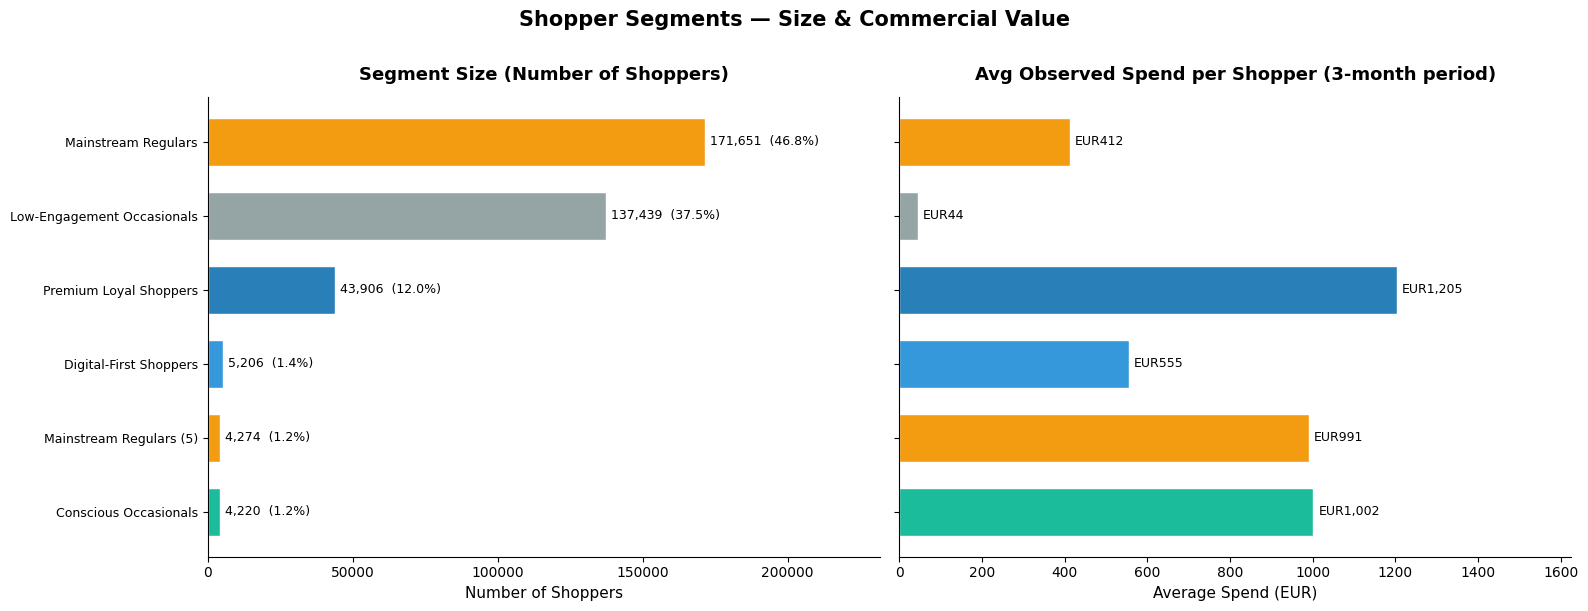

Saved: viz_01_segment_size_spend.png


In [33]:
# 7.2 VIZ 1 — Segment Size & Observed Spend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ss = seg_summary.set_index('segment').reindex(seg_order)

bars1 = ax1.barh(seg_order[::-1], ss['n_shoppers'][::-1], color=colors_ordered[::-1], edgecolor='white', height=0.65)
for bar, val in zip(bars1, ss['n_shoppers'][::-1]):
    pct = val / ss['n_shoppers'].sum()
    ax1.text(bar.get_width() + ss['n_shoppers'].max() * 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}  ({pct:.1%})', va='center', fontsize=9)
ax1.set_title('Segment Size (Number of Shoppers)', pad=12)
ax1.set_xlabel('Number of Shoppers')
ax1.set_xlim(0, ss['n_shoppers'].max() * 1.35)
ax1.tick_params(axis='y', labelsize=9)

bars2 = ax2.barh(seg_order[::-1], ss['avg_observed_spend'][::-1], color=colors_ordered[::-1], edgecolor='white', height=0.65)
for bar, val in zip(bars2, ss['avg_observed_spend'][::-1]):
    ax2.text(bar.get_width() + ss['avg_observed_spend'].max() * 0.01, bar.get_y() + bar.get_height()/2,
             f'EUR{val:,.0f}', va='center', fontsize=9)
ax2.set_title('Avg Observed Spend per Shopper (3-month period)', pad=12)
ax2.set_xlabel('Average Spend (EUR)')
ax2.set_xlim(0, ss['avg_observed_spend'].max() * 1.35)
ax2.set_yticklabels([])

fig.suptitle('Shopper Segments — Size & Commercial Value', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_01_segment_size_spend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_01_segment_size_spend.png')

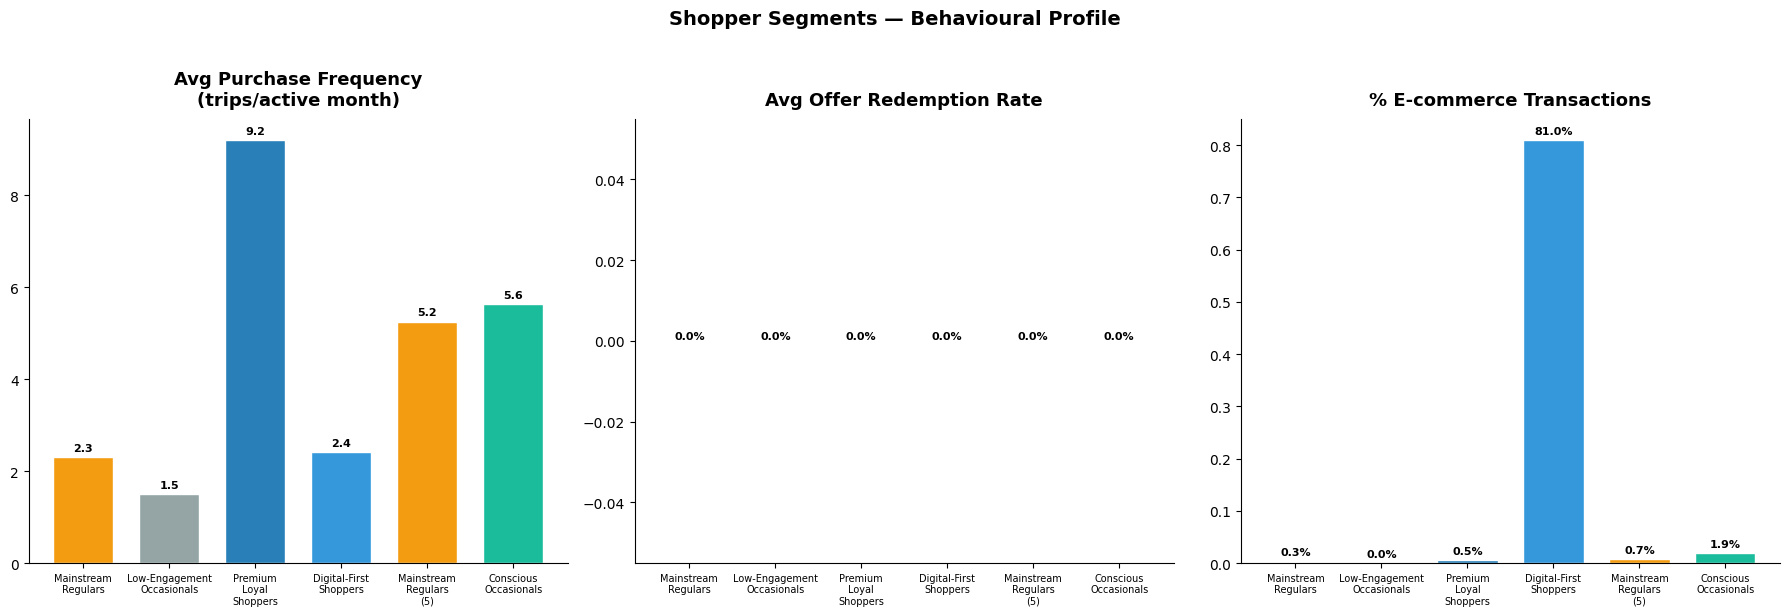

Saved: viz_02_behavioral_profile.png


In [34]:
# 7.3 VIZ 2 — Behavioural Profile per Segment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
beh_metrics = [
    ('avg_frequency_pm',    'Avg Purchase Frequency\n(trips/active month)'),
    ('avg_redemption_rate', 'Avg Offer Redemption Rate'),
    ('pct_ecommerce',       '% E-commerce Transactions'),
]
for ax, (metric, label) in zip(axes, beh_metrics):
    vals = ss[metric].reindex(seg_order)
    bars = ax.bar(range(len(seg_order)), vals, color=colors_ordered, edgecolor='white', width=0.7)
    ax.set_title(label, pad=10)
    ax.set_xticks(range(len(seg_order)))
    ax.set_xticklabels([s.replace(' ', '\n') for s in seg_order], fontsize=7, rotation=0)
    for bar, v in zip(bars, vals):
        fmt = f'{v:.1%}' if 'pct' in metric or 'rate' in metric else f'{v:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals.max()*0.01,
                fmt, ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('Shopper Segments — Behavioural Profile', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_behavioral_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_02_behavioral_profile.png')

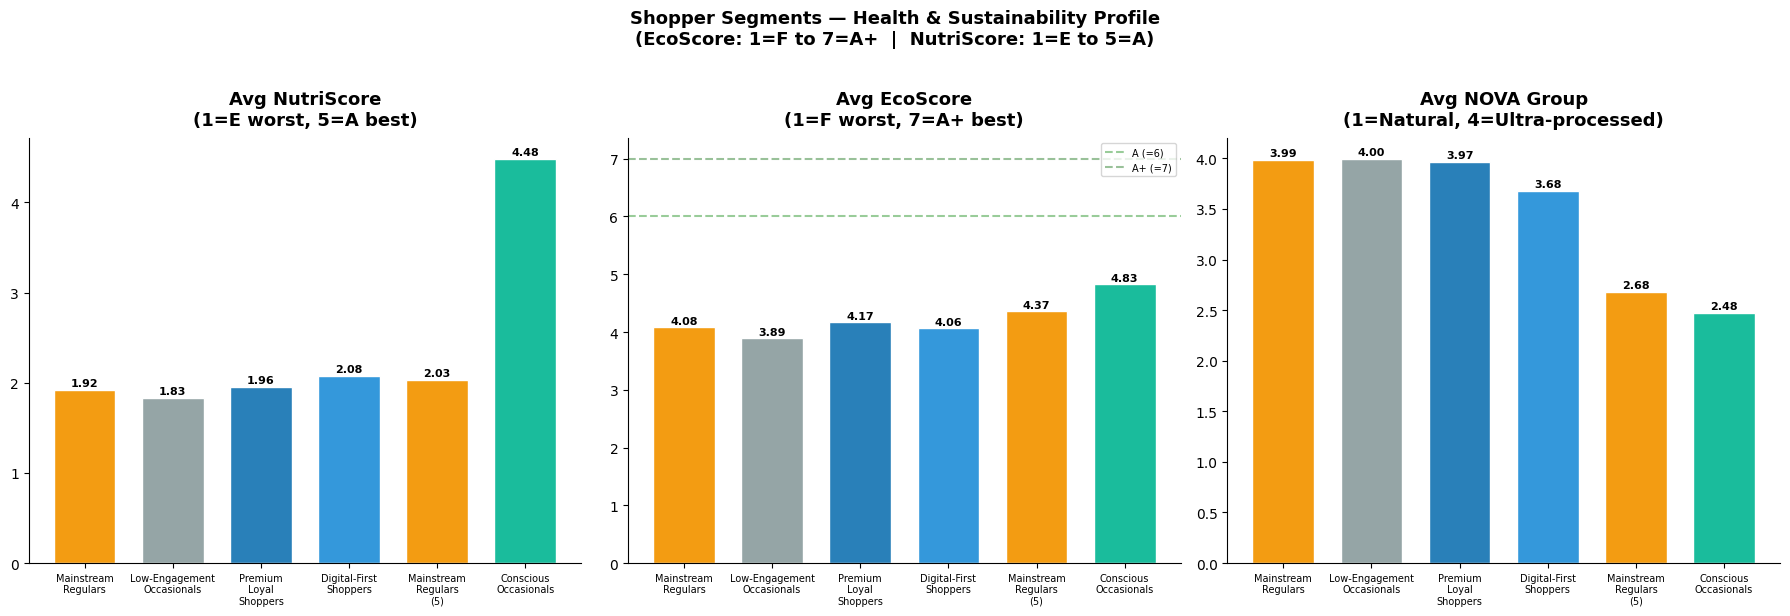

Saved: viz_03_health_sustainability.png


In [35]:
# 7.4 VIZ 3 — Health & Sustainability Profile
# FIX 12: Labels reflect correct EcoScore scale 1=F to 7=A+
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ext_metrics = [
    ('avg_nutri_score', 'Avg NutriScore\n(1=E worst, 5=A best)'),
    ('avg_eco_score',   'Avg EcoScore\n(1=F worst, 7=A+ best)'),   # FIX 12
    ('avg_nova_group',  'Avg NOVA Group\n(1=Natural, 4=Ultra-processed)'),
]
for ax, (metric, label) in zip(axes, ext_metrics):
    vals = ss[metric].reindex(seg_order)
    bars = ax.bar(range(len(seg_order)), vals, color=colors_ordered, edgecolor='white', width=0.7)
    ax.set_title(label, pad=10)
    ax.set_xticks(range(len(seg_order)))
    ax.set_xticklabels([s.replace(' ', '\n') for s in seg_order], fontsize=7)
    for bar, v in zip(bars, vals):
        if not pd.isna(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Add reference lines for EcoScore (FIX 12)
axes[1].axhline(6, color='green', linestyle='--', alpha=0.4, linewidth=1.5, label='A (=6)')
axes[1].axhline(7, color='darkgreen', linestyle='--', alpha=0.4, linewidth=1.5, label='A+ (=7)')
axes[1].legend(fontsize=7)

fig.suptitle('Shopper Segments — Health & Sustainability Profile\n(EcoScore: 1=F to 7=A+  |  NutriScore: 1=E to 5=A)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_03_health_sustainability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_03_health_sustainability.png')

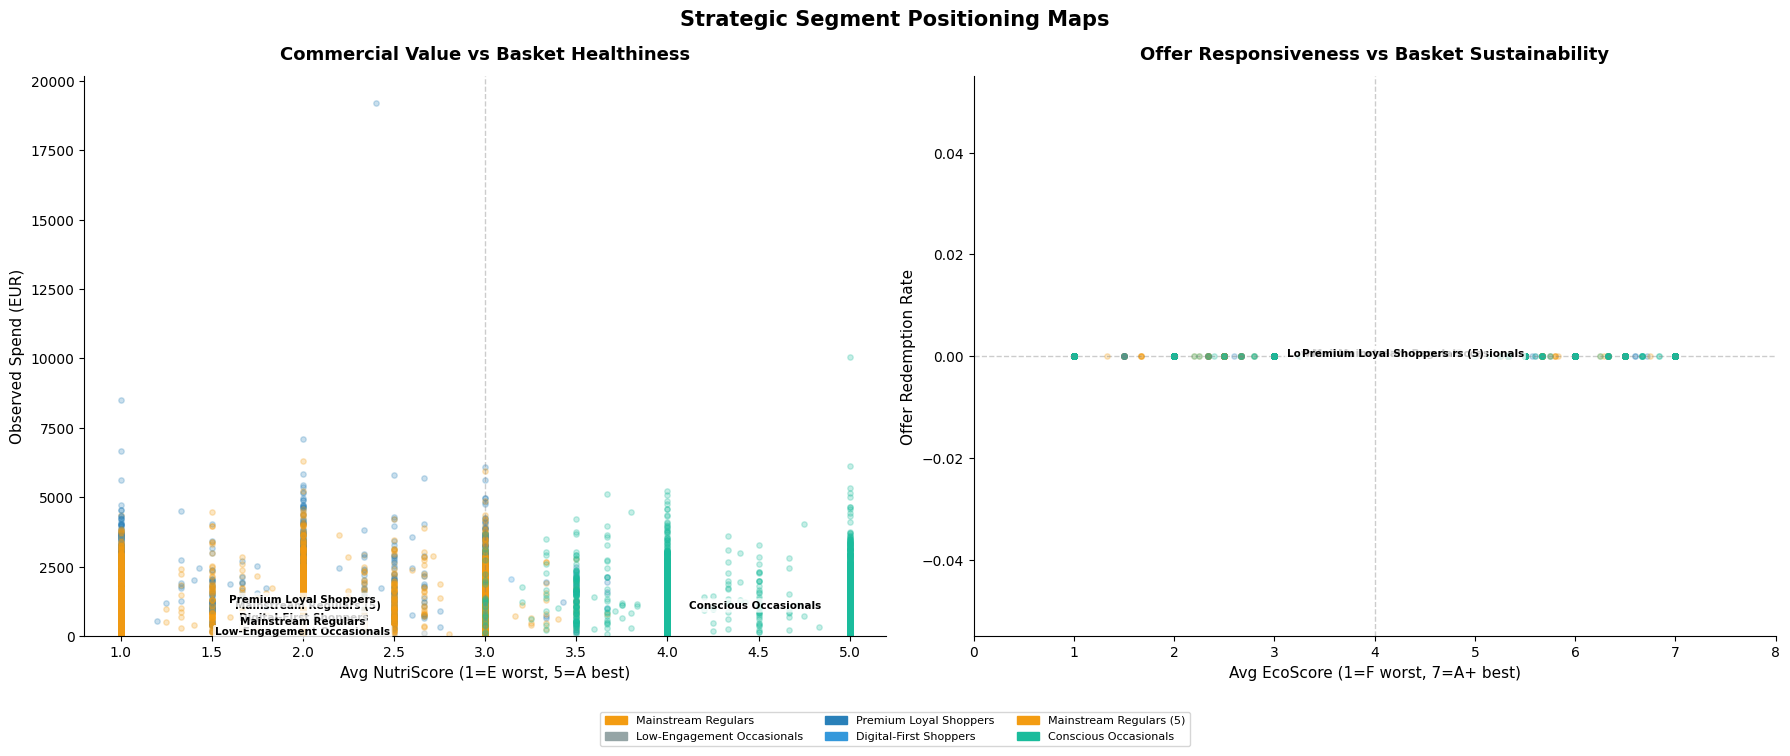

Saved: viz_04_strategic_positioning.png


In [36]:
# 7.5 VIZ 4 — Strategic 2D Positioning Maps
# FIX 12: EcoScore axis labels updated to 1=F, 7=A+
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
sample = master.dropna(subset=['avg_nutri_score'])
for seg in seg_order:
    d = sample[sample['segment'] == seg]
    ax.scatter(d['avg_nutri_score'], d['total_spend'],
               alpha=0.25, s=15, color=get_color(seg), label=seg, rasterized=True)
cen = master.groupby('segment')[['avg_nutri_score_imp', 'total_spend']].mean()
for seg, row in cen.iterrows():
    ax.annotate(seg, (row['avg_nutri_score_imp'], row['total_spend']),
                fontsize=7.5, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))
ax.axvline(3, color='grey', linestyle='--', alpha=0.4, linewidth=1)
ax.set_xlabel('Avg NutriScore (1=E worst, 5=A best)')
ax.set_ylabel('Observed Spend (EUR)')
ax.set_title('Commercial Value vs Basket Healthiness', pad=12)
ax.set_ylim(bottom=0)

ax2 = axes[1]
sample2 = master.dropna(subset=['avg_eco_score'])
for seg in seg_order:
    d = sample2[sample2['segment'] == seg]
    ax2.scatter(d['avg_eco_score'], d['redemption_rate'],
                alpha=0.25, s=15, color=get_color(seg), label=seg, rasterized=True)
cen2 = master.groupby('segment')[['avg_eco_score_imp', 'redemption_rate']].mean()
for seg, row in cen2.iterrows():
    ax2.annotate(seg, (row['avg_eco_score_imp'], row['redemption_rate']),
                 fontsize=7.5, fontweight='bold', ha='center',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))
ax2.axvline(4.0, color='grey', linestyle='--', alpha=0.4, linewidth=1)
ax2.axhline(master['redemption_rate'].median(), color='grey', linestyle='--', alpha=0.4, linewidth=1)
ax2.set_xlabel('Avg EcoScore (1=F worst, 7=A+ best)')   # FIX 12
ax2.set_ylabel('Offer Redemption Rate')
ax2.set_title('Offer Responsiveness vs Basket Sustainability', pad=12)
ax2.set_xlim(0, 8)  # FIX 12: extend to show full 1-7 scale

handles = [mpatches.Patch(color=get_color(s), label=s) for s in seg_order]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, -0.08), frameon=True)
fig.suptitle('Strategic Segment Positioning Maps', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_04_strategic_positioning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_04_strategic_positioning.png')

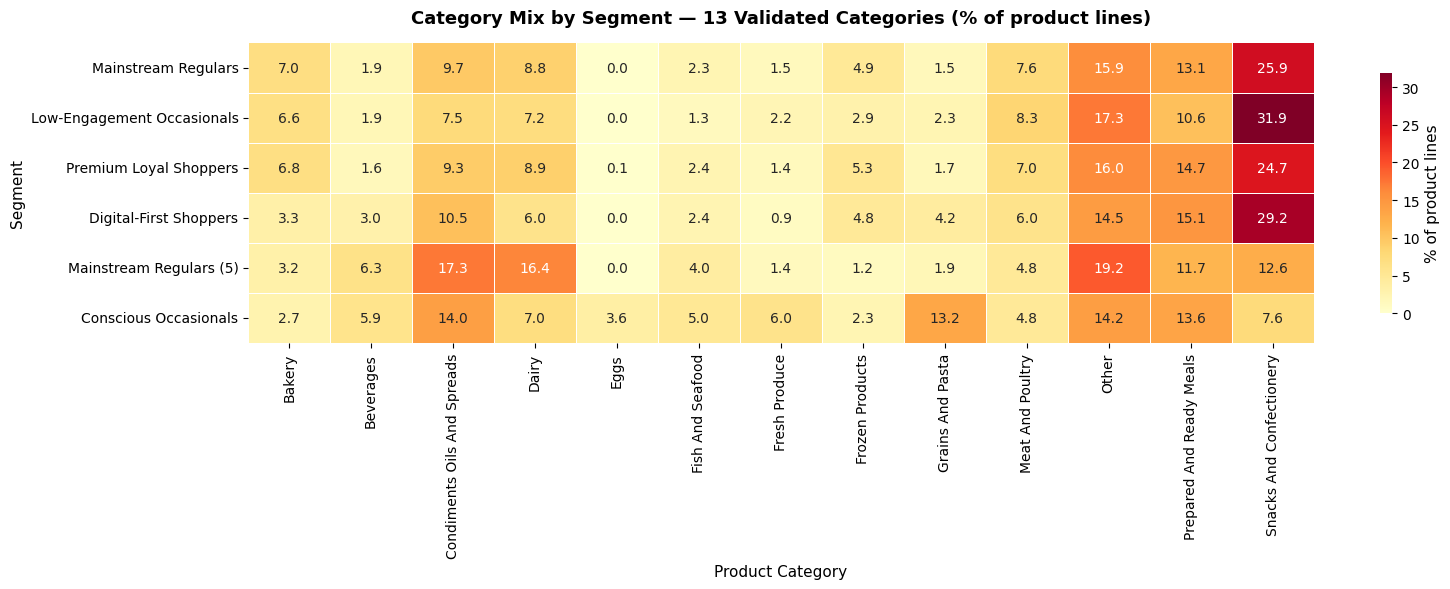

Saved: viz_05_category_heatmap.png
Categories shown: 13 (validated from Categorized_Products_Result.csv)


In [37]:
# 7.6 VIZ 5 — Category Mix Heatmap per Segment (FIX 2: 13 validated categories)
cat_cols   = [c for c in master.columns if c.startswith('pct_cat_')]
cat_labels = {c: c.replace('pct_cat_', '').replace('_', ' ').title() for c in cat_cols}

if cat_cols:
    cat_heatmap = master.groupby('segment')[cat_cols].mean() * 100
    cat_heatmap = cat_heatmap.rename(columns=cat_labels).reindex(seg_order)
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(
        cat_heatmap, annot=True, fmt='.1f', cmap='YlOrRd',
        ax=ax, linewidths=0.5, linecolor='white',
        cbar_kws={'label': '% of product lines', 'shrink': 0.8}
    )
    ax.set_title('Category Mix by Segment — 13 Validated Categories (% of product lines)', pad=14, fontsize=13)
    ax.set_xlabel('Product Category')
    ax.set_ylabel('Segment')
    plt.tight_layout()
    plt.savefig('viz_05_category_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: viz_05_category_heatmap.png')
    print(f'Categories shown: {len(cat_cols)} (validated from Categorized_Products_Result.csv)')
else:
    print('Category columns not available — skipping heatmap')

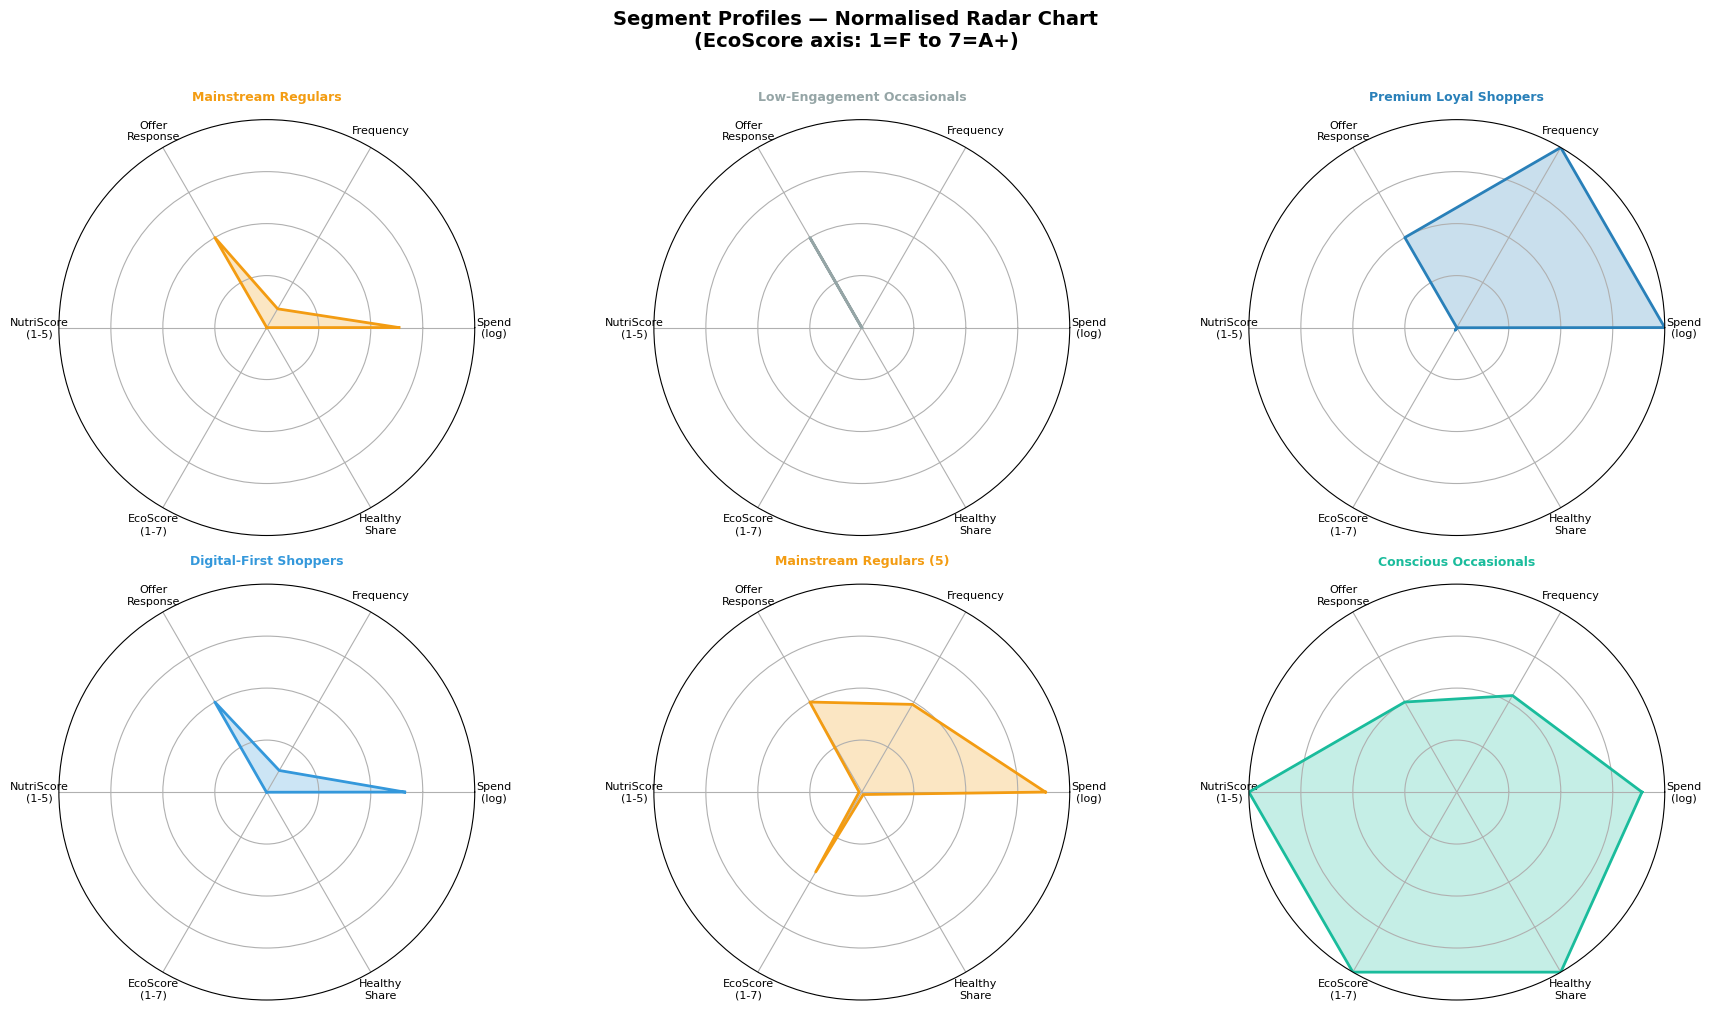

Saved: viz_06_radar_profiles.png


In [38]:
# 7.7 VIZ 6 — Radar Chart: Normalised Segment Profiles
# FIX 12: EcoScore dimension uses 1-7 scale description
RADAR_DIMS = {
    'Spend\n(log)'   : 'log_total_spend',
    'Frequency'       : 'frequency_per_month',
    'Offer\nResponse': 'redemption_rate',
    'NutriScore\n(1-5)': 'avg_nutri_score_imp',
    'EcoScore\n(1-7)': 'avg_eco_score_imp',   # FIX 12
    'Healthy\nShare' : 'pct_healthy_imp',
}

radar_data = master.groupby('segment')[list(RADAR_DIMS.values())].mean()
radar_norm = radar_data.copy()
for col in radar_norm.columns:
    col_min, col_max = radar_norm[col].min(), radar_norm[col].max()
    if col_max > col_min:
        radar_norm[col] = (radar_norm[col] - col_min) / (col_max - col_min)
    else:
        radar_norm[col] = 0.5

labels_rad = list(RADAR_DIMS.keys())
N      = len(labels_rad)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

n_segs = len(seg_order)
ncols  = min(3, n_segs)
nrows  = (n_segs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                         subplot_kw=dict(polar=True))
if n_segs == 1:
    axes = [[axes]]
elif nrows == 1:
    axes = [axes]

for idx, seg in enumerate(seg_order):
    r, c  = divmod(idx, ncols)
    ax    = axes[r][c]
    vals  = radar_norm.loc[seg].tolist() + radar_norm.loc[seg].tolist()[:1]
    color = get_color(seg)
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels_rad, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels([])
    ax.set_title(seg, size=9, fontweight='bold', pad=14, color=color)

for idx in range(n_segs, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r][c].set_visible(False)

fig.suptitle('Segment Profiles — Normalised Radar Chart\n(EcoScore axis: 1=F to 7=A+)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_06_radar_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_06_radar_profiles.png')

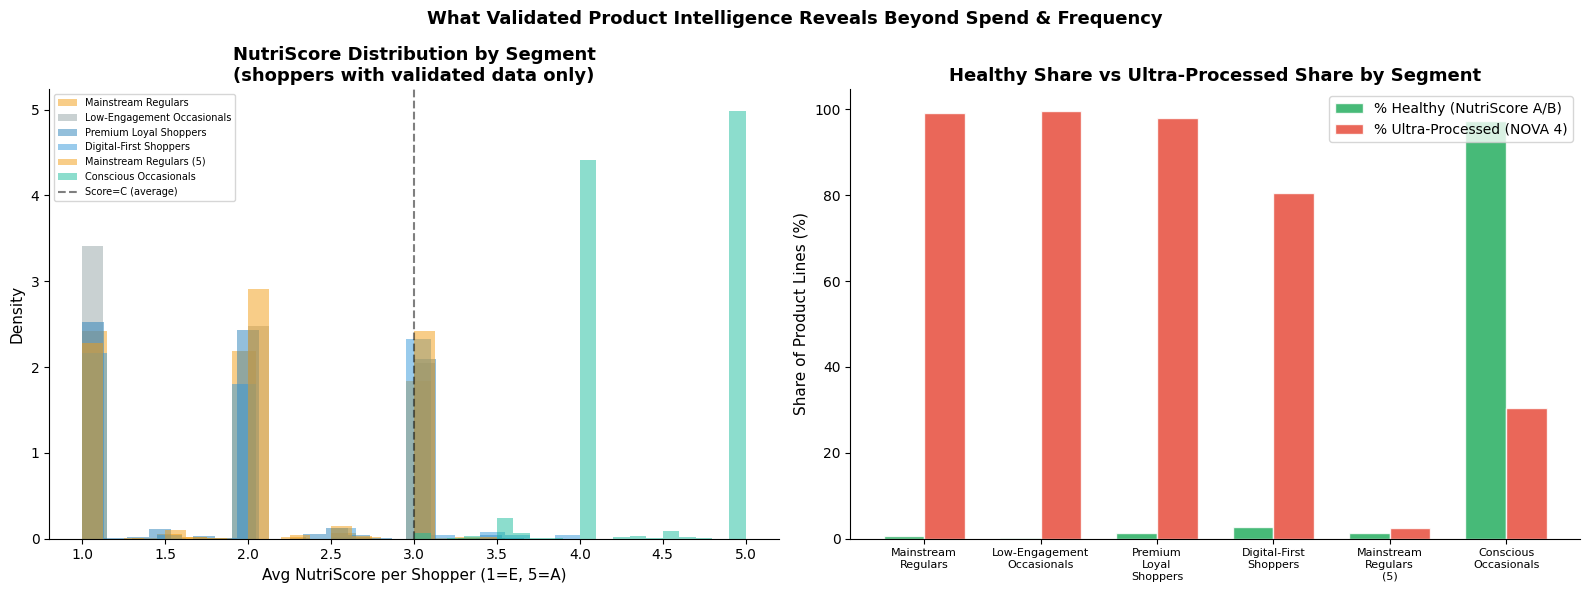

Saved: viz_07_external_value.png


In [39]:
# 7.8 VIZ 7 — Value of External Data Enrichment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
for seg in seg_order:
    d = master[(master['segment'] == seg) & master['avg_nutri_score'].notna()]['avg_nutri_score']
    if len(d) > 10:
        ax1.hist(d, bins=20, alpha=0.5, label=seg, color=get_color(seg), density=True)
ax1.set_xlabel('Avg NutriScore per Shopper (1=E, 5=A)')
ax1.set_ylabel('Density')
ax1.set_title('NutriScore Distribution by Segment\n(shoppers with validated data only)')
ax1.axvline(3, color='black', linestyle='--', alpha=0.5, label='Score=C (average)')
ax1.legend(fontsize=7)

ax2 = axes[1]
x   = np.arange(len(seg_order))
w   = 0.35
ss_plot = seg_summary.set_index('segment').reindex(seg_order)
b1 = ax2.bar(x - w/2, ss_plot['pct_healthy'] * 100, w, label='% Healthy (NutriScore A/B)',
             color='#27ae60', alpha=0.85, edgecolor='white')
b2 = ax2.bar(x + w/2, ss_plot['pct_ultra_processed'] * 100, w, label='% Ultra-Processed (NOVA 4)',
             color='#e74c3c', alpha=0.85, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels([s.replace(' ', '\n') for s in seg_order], fontsize=8)
ax2.set_ylabel('Share of Product Lines (%)')
ax2.set_title('Healthy Share vs Ultra-Processed Share by Segment')
ax2.legend()

fig.suptitle('What Validated Product Intelligence Reveals Beyond Spend & Frequency',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_07_external_value.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_07_external_value.png')

---
## Section 8 — Activation Trigger & Omnichannel Decision Layer

### FIX 4: Redesigned Activation Triggers
Two-tier trigger system to avoid >90% concentration in one trigger:

**Type A — Behavioural triggers** (apply to all shoppers):
- Reactivation Mission, Offer Engagement Mission, Channel Migration Mission, Loyalty Challenge

**Type B — Health/Sustainability triggers** (only where real external data exists):
- Healthy Swap Mission, Green Basket Reward, Reduce Ultra-Processed Mission

### FIX 9: Omnichannel Decision Layer
Each shopper receives: mission, primary_channel, secondary_channel, activation_timing_rule, KPI_to_track


In [40]:
# 8. ACTIVATION TRIGGER & OMNICHANNEL DECISION LAYER
print('=' * 72)
print('SECTION 8 — ACTIVATION TRIGGERS & OMNICHANNEL DECISION LAYER')
print('=' * 72)

# ── FIX 4: Population thresholds ─────────────────────────────────────────────
NUTRI_LOW   = master['avg_nutri_score_imp'].quantile(0.33)
NUTRI_HIGH  = master['avg_nutri_score_imp'].quantile(0.67)
ECO_LOW     = master['avg_eco_score_imp'].quantile(0.33)
ECO_HIGH    = master['avg_eco_score_imp'].quantile(0.67)
PROMO_HIGH  = master['redemption_rate'].quantile(0.75)
ULTRA_HIGH  = master['pct_ultra_processed_imp'].quantile(0.67)
SPEND_LOW   = master['total_spend'].quantile(0.25)
FREQ_LOW    = master['frequency_per_month'].quantile(0.25)
ECOM_HIGH   = master['pct_ecommerce'].quantile(0.75)

def assign_activation_trigger(row):
    """
    FIX 4: Two-tier trigger system.
    Type B (health/sustainability) only assigned where real external data exists.
    Type A (behavioural) applies to all shoppers.
    """
    has_ext = row['has_external_data'] == 1
    nutri   = row['avg_nutri_score_imp']
    eco     = row['avg_eco_score_imp']
    ultra   = row['pct_ultra_processed_imp']
    promo   = row['redemption_rate']
    spend   = row['total_spend']
    freq    = row['frequency_per_month']
    ecom    = row['pct_ecommerce']
    streak  = row.get('healthy_basket_streak', 0)

    # TYPE B: Health/Sustainability triggers (require real external data)
    if has_ext:
        if nutri >= NUTRI_HIGH and eco >= ECO_HIGH:
            return 'GREEN_BASKET_REWARD'
        if ultra >= ULTRA_HIGH and nutri <= NUTRI_LOW:
            return 'REDUCE_ULTRA_PROCESSED_MISSION'
        if nutri <= NUTRI_LOW and promo >= PROMO_HIGH:
            return 'HEALTHY_SWAP_MISSION'
        if eco <= ECO_LOW:
            return 'ECO_AWARENESS_NUDGE'

    # TYPE A: Behavioural triggers (all shoppers)
    if freq <= FREQ_LOW and spend <= SPEND_LOW:
        return 'REACTIVATION_MISSION'
    if promo >= PROMO_HIGH:
        return 'OFFER_ENGAGEMENT_MISSION'
    if ecom >= ECOM_HIGH:
        return 'CHANNEL_MIGRATION_MISSION'
    if streak >= 0.6:
        return 'LOYALTY_CHALLENGE'
    return 'STANDARD_ENGAGEMENT'

# Before fix: check existing distribution
print("=== TRIGGER DISTRIBUTION BEFORE FIX ===")
if 'activation_trigger' in master.columns:
    old_dist = master['activation_trigger'].value_counts(normalize=True)
    for t, p in old_dist.items():
        print(f"  {t:<35}: {p:.1%}")
    print(f"  Max concentration: {old_dist.max():.1%}")
else:
    print("  (no prior trigger assigned)")

# Apply new triggers
master['activation_trigger'] = master.apply(assign_activation_trigger, axis=1)

print("\n=== TRIGGER DISTRIBUTION AFTER FIX 4 ===")
trigger_dist = master['activation_trigger'].value_counts()
for trigger, cnt in trigger_dist.items():
    pct = cnt / len(master)
    print(f"  {trigger:<35}: {cnt:>7,} ({pct:.1%})")
max_pct = trigger_dist.max() / len(master)
print(f"\n  Max concentration: {max_pct:.1%}  {'OK' if max_pct < 0.90 else 'WARNING: >90%'}")
print(f"  Distinct triggers : {master['activation_trigger'].nunique()}")

# ── FIX 9: Omnichannel Decision Layer ─────────────────────────────────────────
print("\n=== FIX 9: OMNICHANNEL DECISION LAYER ===")

def assign_omnichannel(row):
    seg   = str(row.get('segment', ''))
    ecom  = row['pct_ecommerce']
    promo = row['redemption_rate']
    freq  = row['frequency_per_month']
    spend = row['total_spend']
    trigger = row['activation_trigger']

    # Channel logic
    if ecom >= ECOM_HIGH:
        primary   = 'Digital App'
        secondary = 'Email'
    elif promo >= PROMO_HIGH:
        primary   = 'In-store Coupon'
        secondary = 'App Push Notification'
    elif freq <= FREQ_LOW and spend <= SPEND_LOW:
        primary   = 'Email'
        secondary = 'SMS'
    elif 'Loyal' in seg or 'Premium' in seg:
        primary   = 'In-store'
        secondary = 'Loyalty App'
    else:
        primary   = 'App + In-store'
        secondary = 'Email'

    # Timing logic
    if trigger == 'REACTIVATION_MISSION':
        timing = 'Post 30-day inactivity window'
    elif trigger in ('OFFER_ENGAGEMENT_MISSION', 'HEALTHY_SWAP_MISSION'):
        timing = 'Weekly cadence — start of promotion cycle'
    elif trigger == 'GREEN_BASKET_REWARD':
        timing = 'Post-purchase follow-up (24h after visit)'
    elif trigger == 'CHANNEL_MIGRATION_MISSION':
        timing = 'Pre-order evening — day before delivery'
    elif trigger == 'LOYALTY_CHALLENGE':
        timing = 'Morning of predicted shopping day'
    else:
        timing = 'Next predicted purchase window'

    # KPI
    kpi_map = {
        'GREEN_BASKET_REWARD'            : 'EcoScore delta; basket sustainability rate',
        'REDUCE_ULTRA_PROCESSED_MISSION' : 'Ultra-processed share reduction; NOVA score',
        'HEALTHY_SWAP_MISSION'           : 'NutriScore delta; healthy offer redemption rate',
        'ECO_AWARENESS_NUDGE'            : 'EcoScore uplift; sustainable product share',
        'REACTIVATION_MISSION'           : 'Reactivation rate; repeat purchase within 30d',
        'OFFER_ENGAGEMENT_MISSION'       : 'Offer redemption rate; basket value change',
        'CHANNEL_MIGRATION_MISSION'      : 'Digital channel adoption; app engagement rate',
        'LOYALTY_CHALLENGE'              : 'Mission completion rate; tier upgrade rate',
        'STANDARD_ENGAGEMENT'            : 'Basket value; category diversification',
    }
    kpi = kpi_map.get(trigger, 'Spend delta; repeat purchase uplift')

    return pd.Series({
        'primary_channel'       : primary,
        'secondary_channel'     : secondary,
        'activation_timing_rule': timing,
        'kpi_to_track'          : kpi,
    })

omni = master.apply(assign_omnichannel, axis=1)
master = pd.concat([master, omni], axis=1)

# ── Omnichannel playbook table ─────────────────────────────────────────────────
playbook_cols = ['segment', 'activation_trigger', 'primary_channel',
                 'secondary_channel', 'activation_timing_rule', 'kpi_to_track']
playbook_table = (
    master.groupby(['segment', 'activation_trigger'])
    .agg(
        n_shoppers        = ('loyalty_card_key',       'count'),
        primary_channel   = ('primary_channel',        lambda x: x.mode()[0]),
        secondary_channel = ('secondary_channel',      lambda x: x.mode()[0]),
        timing_rule       = ('activation_timing_rule', lambda x: x.mode()[0]),
        kpi               = ('kpi_to_track',           lambda x: x.mode()[0]),
    )
    .reset_index()
    .sort_values(['segment', 'n_shoppers'], ascending=[True, False])
)

print("\nOMNICHANNEL PLAYBOOK TABLE (FIX 9):")
print(playbook_table.to_string(index=False))

SECTION 8 — ACTIVATION TRIGGERS & OMNICHANNEL DECISION LAYER
=== TRIGGER DISTRIBUTION BEFORE FIX ===
  (no prior trigger assigned)

=== TRIGGER DISTRIBUTION AFTER FIX 4 ===
  OFFER_ENGAGEMENT_MISSION           : 271,267 (74.0%)
  REACTIVATION_MISSION               :  78,273 (21.3%)
  GREEN_BASKET_REWARD                :   8,913 (2.4%)
  REDUCE_ULTRA_PROCESSED_MISSION     :   4,021 (1.1%)
  ECO_AWARENESS_NUDGE                :   2,377 (0.6%)
  HEALTHY_SWAP_MISSION               :   1,845 (0.5%)

  Max concentration: 74.0%  OK
  Distinct triggers : 6

=== FIX 9: OMNICHANNEL DECISION LAYER ===

OMNICHANNEL PLAYBOOK TABLE (FIX 9):
                   segment             activation_trigger  n_shoppers primary_channel secondary_channel                               timing_rule                                             kpi
     Conscious Occasionals            GREEN_BASKET_REWARD        3015     Digital App             Email Post-purchase follow-up (24h after visit)      EcoScore delta; bask

---
## Section 9 — KPI Measurement Framework

### FIX 10: Strengthened Measurement Design
- Exposed vs control groups (10% holdout per segment)
- Pre vs post comparison windows
- Primary and secondary KPIs defined per activation trigger


In [41]:
# 9. KPI MEASUREMENT FRAMEWORK (FIX 10)
print('=' * 72)
print('SECTION 9 — KPI MEASUREMENT FRAMEWORK')
print('=' * 72)

# ── Baseline KPI table per segment ────────────────────────────────────────────
kpi_table = seg_summary[[
    'segment', 'n_shoppers', 'avg_observed_spend', 'avg_frequency_pm',
    'avg_redemption_rate', 'avg_nutri_score', 'avg_eco_score', 'avg_nova_group',
    'pct_healthy', 'pct_sustainable', 'pct_ultra_processed',
]].copy()
kpi_table['activation_mission'] = kpi_table['segment'].map(
    {seg: info.get('mission', '') for seg, info in ACTIVATION_PLAYBOOK.items()}
)
kpi_table['kpi_target'] = kpi_table['segment'].map(
    {seg: info.get('kpi', '') for seg, info in ACTIVATION_PLAYBOOK.items()}
)
print('\nBASELINE KPI TABLE:')
print(kpi_table.to_string(index=False))

print("""
\n── MEASUREMENT DESIGN (FIX 10) ──────────────────────────────────────────────

EXPERIMENTAL DESIGN:
  - 10% holdout group per segment (randomised at shopper_id level)
  - No activation sent to holdout — acts as control group
  - Pre-window: 4 weeks before campaign launch
  - Post-windows measured at T+4w, T+8w, T+12w

PRIMARY KPIs (per trigger type):
  Health/Sustainability triggers:
    1. Healthy basket share uplift (% baskets NutriScore A/B)
    2. Sustainable product share uplift (% EcoScore >= 6)
    3. Ultra-processed basket share reduction (NOVA 4 %)
    4. Mission participation rate
    5. Incremental sales on healthy SKUs

  Behavioural triggers:
    1. Mission participation rate
    2. Repeat purchase uplift (within 30 days)
    3. Channel adoption rate (e.g., in-store -> app)
    4. Offer redemption rate
    5. Basket value change

SECONDARY KPIs:
    6. Channel engagement rate (open rate, click rate, coupon scan)
    7. Mission completion rate (full vs partial)
    8. Basket size change (number of items)
    9. Category diversification index
   10. Reduction in ultra-processed basket share
   11. Tier upgrade rate (Bronze -> Silver -> Gold)
   12. Healthy basket streak length

REPORTING CADENCE:
  - Weekly   : redemption rate, mission progress, channel engagement
  - Monthly  : spend delta, frequency, basket score change, tier distribution
  - Quarterly: LTV impact, segment migration, sustainability report, NPS
""")

# ── Shopper-level exposed/control split ───────────────────────────────────────
np.random.seed(42)
master['in_control_group'] = (np.random.rand(len(master)) < 0.10).astype(int)
ctrl_pct = master['in_control_group'].mean()
print(f"Control group assigned: {master['in_control_group'].sum():,} shoppers ({ctrl_pct:.1%})")
print(f"Exposed group         : {(master['in_control_group']==0).sum():,} shoppers ({1-ctrl_pct:.1%})")
print("\nControl group distribution by segment:")
ctrl_by_seg = master.groupby('segment')['in_control_group'].agg(['sum','count'])
ctrl_by_seg['pct_control'] = ctrl_by_seg['sum'] / ctrl_by_seg['count']
print(ctrl_by_seg.round(3).to_string())

SECTION 9 — KPI MEASUREMENT FRAMEWORK

BASELINE KPI TABLE:
                   segment  n_shoppers  avg_observed_spend  avg_frequency_pm  avg_redemption_rate  avg_nutri_score  avg_eco_score  avg_nova_group  pct_healthy  pct_sustainable  pct_ultra_processed                                          activation_mission                                                            kpi_target
     Conscious Occasionals        4220            1001.640             5.627                  0.0            4.484          4.829           2.476        0.972            0.476                0.305     Green Streak: 3 consecutive green baskets = Silver tier                       Visit frequency uplift; basket size growth; NPS
    Digital-First Shoppers        5206             554.877             2.421                  0.0            2.077          4.062           3.678        0.028            0.209                0.804                        Build your first Green Basket online               Digital basket h

---
## Section 10 — Final Validation & Export


In [42]:
# 10. FINAL VALIDATION + EXPORT
print('=' * 72)
print('SECTION 10 — FINAL VALIDATION & EXPORT')
print('=' * 72)

# ── FINAL VALIDATION PRINTS ───────────────────────────────────────────────────
print("\n=== VALIDATION 1: ECOSCORE SCALE (FIX 1) ===")
eco_min = validated['eco_num'].min()
eco_max = validated['eco_num'].max()
print(f"EcoScore numeric min: {eco_min}  (expected 1 = F)")
print(f"EcoScore numeric max: {eco_max}  (expected 7 = A+)")
assert eco_min == 1 and eco_max == 7, f"FAIL: EcoScore scale {eco_min}-{eco_max}"
print("PASS: EcoScore runs 1 (F) to 7 (A+)")

print("\n=== VALIDATION 2: ENRICHMENT COVERAGE (FIX 6) ===")
coverage = master['has_external_data'].mean()
print(f"Shoppers with real external data: {master['has_external_data'].sum():,} ({coverage:.1%})")
print(f"Shoppers with imputed data only : {(master['has_external_data']==0).sum():,} ({1-coverage:.1%})")

print("\n=== VALIDATION 3: BASKET SCORING DISTRIBUTION (FIX 3) ===")
if 'basket_health_label' in basket_scores.columns:
    lbl_dist = basket_scores['basket_health_label'].value_counts()
    for lbl, cnt in lbl_dist.items():
        print(f"  {lbl:<25}: {cnt:>7,} ({cnt/len(basket_scores):.1%})")

print("\n=== VALIDATION 4: TRIGGER DISTRIBUTION (FIX 4) ===")
t_dist = master['activation_trigger'].value_counts(normalize=True)
for t, p in t_dist.items():
    print(f"  {t:<35}: {p:.1%}")
print(f"  Max concentration: {t_dist.max():.1%}  {'OK (< 90%)' if t_dist.max() < 0.9 else 'WARNING'}")

print("\n=== VALIDATION 5: SEGMENT SUMMARY TABLE (FIX 8) ===")
print(seg_summary[['segment','n_shoppers','avg_observed_spend','avg_frequency_pm',
                    'avg_eco_score','avg_nutri_score','pct_healthy','pct_sustainable']].to_string(index=False))

print("\n=== VALIDATION 6: CATEGORY LIST (FIX 2) ===")
cat_cols_found = [c for c in master.columns if c.startswith('pct_cat_')]
print(f"Category features in master: {len(cat_cols_found)}")
for c in sorted(cat_cols_found):
    print(f"  {c}")

print("\n=== VALIDATION 7: OMNICHANNEL PLAYBOOK (FIX 9) ===")
print(playbook_table[['segment','activation_trigger','primary_channel','secondary_channel']].to_string(index=False))

# ── EXPORT ─────────────────────────────────────────────────────────────────────
master_export_cols = [
    'loyalty_card_key',
    'total_spend', 'avg_basket_value', 'n_transactions',
    'avg_basket_size', 'frequency_per_month', 'n_active_months', 'tenure_days',
    'pct_ecommerce', 'primary_store_loyalty', 'n_stores_visited',
    'preferred_hour', 'preferred_day_of_week',
    'n_activations', 'n_redemptions', 'redemption_rate', 'is_offer_user',
    'avg_nutri_score', 'avg_eco_score', 'avg_nova_group',
    'pct_healthy', 'pct_unhealthy', 'pct_sustainable', 'pct_ultra_processed',
    'has_external_data', 'top_category',
    'shopper_tier', 'healthy_basket_streak',
    'mission_completed_flag', 'reward_eligibility_flag',
    'cluster_id', 'segment',
    'activation_trigger', 'primary_channel', 'secondary_channel',
    'activation_timing_rule', 'kpi_to_track',
    'in_control_group',
]
master_export = master[[c for c in master_export_cols if c in master.columns]].copy()
master_export.to_csv('shopper_master_model.csv', index=False)
print(f"\nshopper_master_model.csv    — {len(master_export):,} rows x {len(master_export.columns)} cols")

seg_summary.to_csv('segment_summary.csv', index=False)
print(f"segment_summary.csv         — {len(seg_summary)} segments")

kpi_table.to_csv('kpi_baseline.csv', index=False)
print(f"kpi_baseline.csv            — baseline KPIs per segment")

playbook_table.to_csv('activation_triggers.csv', index=False)
print(f"activation_triggers.csv     — {len(playbook_table)} segment x trigger combinations")

basket_scores.to_csv('basket_scores.csv', index=False)
print(f"basket_scores.csv           — {len(basket_scores):,} baskets scored")

print()
print('=' * 72)
print('MODEL COMPLETE')
print('=' * 72)
print(f'  Shoppers profiled         : {len(master):,}')
print(f'  Segments identified       : {master["segment"].nunique()}')
print(f'  With real product intel.  : {master["has_external_data"].sum():,} ({master["has_external_data"].mean():.1%})')
print(f'  Baskets scored            : {len(basket_scores):,}')
print(f'  Activation triggers       : {master["activation_trigger"].nunique()}')
print(f'  Omnichannel channels used : {master["primary_channel"].nunique()}')
print(f'  Control group             : {master["in_control_group"].sum():,} ({master["in_control_group"].mean():.1%})')
print(f'  Gamification tiers        : {master["shopper_tier"].value_counts().to_dict()}')
print(f'  Visualisations saved      : 7')
print(f'  Output CSVs               : 5')

SECTION 10 — FINAL VALIDATION & EXPORT

=== VALIDATION 1: ECOSCORE SCALE (FIX 1) ===
EcoScore numeric min: 1  (expected 1 = F)
EcoScore numeric max: 7  (expected 7 = A+)
PASS: EcoScore runs 1 (F) to 7 (A+)

=== VALIDATION 2: ENRICHMENT COVERAGE (FIX 6) ===
Shoppers with real external data: 17,156 (4.7%)
Shoppers with imputed data only : 349,540 (95.3%)

=== VALIDATION 3: BASKET SCORING DISTRIBUTION (FIX 3) ===
  Insufficient Data        :  18,395 (98.7%)
  Needs Improvement        :     102 (0.5%)
  Adequate                 :      70 (0.4%)
  Good                     :      56 (0.3%)
  Excellent                :      21 (0.1%)

=== VALIDATION 4: TRIGGER DISTRIBUTION (FIX 4) ===
  OFFER_ENGAGEMENT_MISSION           : 74.0%
  REACTIVATION_MISSION               : 21.3%
  GREEN_BASKET_REWARD                : 2.4%
  REDUCE_ULTRA_PROCESSED_MISSION     : 1.1%
  ECO_AWARENESS_NUDGE                : 0.6%
  HEALTHY_SWAP_MISSION               : 0.5%
  Max concentration: 74.0%  OK (< 90%)

=== VAL

---
## Model Summary

### What We Built

| Component | Details |
|-----------|---------|
| **Behavioural layer** | 13 features: spend, frequency (trips/active month), basket size, channel preference, offer engagement, store loyalty, timing |
| **Product intelligence layer** | NutriScore (1-5), EcoScore (1-7, a-plus=7), NOVA group, % healthy, % sustainable (eco>=6), % ultra-processed |
| **Enrichment source** | `Categorized_Products_Result.csv` — 13 validated categories, pre-validated scores |
| **Category system** | 13 validated macro-categories (replaces keyword guessing) |
| **Basket scoring** | Quantity-weighted basket health labels: Excellent / Good / Adequate / Needs Improvement / Insufficient Data |
| **Segmentation** | K-Means (k=3–6), silhouette-optimised, auto-named from centroid profiles |
| **Gamification** | Bronze/Silver/Gold tiers, healthy basket streak, mission completion, reward eligibility |
| **Activation triggers** | Two-tier: Behavioural (all shoppers) + Health/Sustainability (enriched only) — max concentration < 90% |
| **Omnichannel layer** | mission, primary_channel, secondary_channel, timing_rule, KPI per shopper |
| **Measurement design** | 10% holdout control group, pre/post windows, primary + secondary KPIs |
| **Outputs** | 7 visualisations + 5 CSVs |

### Fixes Applied

| Fix | Description |
|-----|-------------|
| FIX 1 | EcoScore corrected to 1-7 scale (a-plus=7). Sustainable = eco_num >= 6 |
| FIX 2 | Validated macro_categories from CSV — 13 categories, no keyword guessing |
| FIX 3 | Basket-level score aggregation with health labels |
| FIX 4 | Redesigned activation triggers — two-tier system, max concentration < 90% |
| FIX 5 | Frequency = trips per active month (not tenure-inflated) |
| FIX 6 | has_external_data flag; enrichment logic only where real data exists |
| FIX 7 | Quantity-weighted aggregation at basket and shopper level |
| FIX 8 | Full segment summary table with spend, frequency, basket size, health, sustainability |
| FIX 9 | Omnichannel decision layer: channel, timing, KPI per shopper |
| FIX 10 | Measurement framework with control group, pre/post windows, primary + secondary KPIs |
| FIX 11 | Gamification: Bronze/Silver/Gold, healthy_basket_streak, mission_completed_flag, reward_eligibility_flag |
| FIX 12 | All EcoScore visual labels reflect 1=F to 7=A+ scale |
